**Preprocessing**

In [10]:
import pandas as pd
import re
from decimal import Decimal, InvalidOperation

# ============================================================
# CONFIG
# ============================================================
QUESTION_FILE  = "gsm8k/gsm8k_perturbed_full.csv"
RATIONALE_FILE = "gsm8k/gsm8k_gemini_CoT_responses_correct.csv"
OUTPUT_FILE    = "gsm8k/gsm8k_preprocessed_for_logprobs_gemini.csv"

# Your prompts will end with this (MCQ-style)
ANSWER_SLOT = "Select the correct option:"
KILL_ZONE_LEN = 800

NUM_TOKEN_RE = re.compile(r"""
    (?<![\w/])               # not preceded by word char or '/'
    \$?\s*                   # optional dollar sign + spaces
    [-+]?                    # optional sign
    \d[\d,]*                 # digits + optional commas
    (?:\.\d+)?               # optional decimals
    (?![\w/])                # not followed by word char or '/'
""", re.VERBOSE)

# ============================================================
# NUMERIC HELPERS
# ============================================================
def _to_decimal(s: str):
    if s is None:
        return None
    s = str(s).strip()
    if not s:
        return None
    s = s.replace("$", "").replace(",", "").strip()
    try:
        return Decimal(s)
    except (InvalidOperation, ValueError):
        return None

def _decimal_equal(a: Decimal, b: Decimal) -> bool:
    if a is None or b is None:
        return False
    if a == 0 and b == 0:
        return True
    return a.normalize() == b.normalize()

def _extract_numeric_tokens_with_spans(text: str):
    out = []
    for m in NUM_TOKEN_RE.finditer(text):
        raw = m.group(0)
        dec = _to_decimal(raw)
        out.append((m.start(), m.end(), raw, dec))
    return out

# ============================================================
# STEP-HEADER / DANGLING-LINE REMOVAL
# ============================================================
def _normalize_line_for_header_check(line: str) -> str:
    s = line.strip()
    s = re.sub(r"[*_`]+", "", s)               # remove **bold**, _italics_, `code`
    s = re.sub(r"^\s*[-•]\s*", "", s)          # remove bullets
    s = re.sub(r"\s+", " ", s).strip()
    return s

def _looks_like_dangling_step_header(line: str) -> bool:
    if not line or not line.strip():
        return True

    s = _normalize_line_for_header_check(line)

    # If it contains computation operators, it's probably real content
    if any(op in s for op in ["=", "+", "*", "/", "×", "÷"]):
        return False

    if s.endswith(":"):
        return True

    if re.match(r"^(step\s*\d+|\d+\s*[\.\)])\s*[:\-–—]?\s*\w+",
                s, flags=re.IGNORECASE):
        return True

    return False

def drop_trailing_step_headers(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""

    lines = text.split("\n")
    while lines and not lines[-1].strip():
        lines.pop()

    while lines and _looks_like_dangling_step_header(lines[-1]):
        lines.pop()
        while lines and not lines[-1].strip():
            lines.pop()

    return "\n".join(lines).strip()

# ============================================================
# NEW: SPAN REPLACER (mask token, keep line)
# ============================================================
def _replace_span(text: str, start: int, end: int, replacement: str) -> str:
    if not isinstance(text, str):
        return ""
    if start < 0 or end < 0 or start >= end or end > len(text):
        return text
    return text[:start] + replacement + text[end:]

# ============================================================
# LEAKAGE CLEANER (MASK answer token instead of deleting line)
# ============================================================
def clean_rationale_aggressive(text: str, answer_val: str) -> str:
    """
    1) Remove lines with "\\boxed" or "Final Answer"
    2) In last KILL_ZONE_LEN chars, find last numeric token equal to answer_val
       and MASK ONLY THAT NUMBER with [ANS] (do NOT delete whole line).
    3) If last line is only a number equal to target, replace it with [ANS]
    4) Remove trailing dangling step headers
    """
    if not isinstance(text, str):
        return ""

    # Step A: remove explicit "Final Answer"/boxed lines
    lines = text.split("\n")
    kept = []
    for line in lines:
        if "\\boxed" in line or "Final Answer" in line:
            continue
        kept.append(line)
    current_text = "\n".join(kept).strip()

    target_dec = _to_decimal(answer_val) if answer_val else None

    # Step B: find last target occurrence in kill zone and mask just that span
    if target_dec is not None and current_text:
        if len(current_text) <= KILL_ZONE_LEN:
            search_block = current_text
            offset = 0
        else:
            search_block = current_text[-KILL_ZONE_LEN:]
            offset = len(current_text) - KILL_ZONE_LEN

        tokens = _extract_numeric_tokens_with_spans(search_block)

        last_match = None
        for (st, en, raw, dec) in tokens:
            if _decimal_equal(dec, target_dec):
                last_match = (st, en, raw, dec)

        if last_match is not None:
            global_start = offset + last_match[0]
            global_end   = offset + last_match[1]

            current_text = _replace_span(current_text, global_start, global_end, " [ANS] ")
            current_text = re.sub(r"[ \t]{2,}", " ", current_text).strip()

    # Step C: if trailing numeric-only line equals target, mask it
    if target_dec is not None and current_text:
        lines = current_text.split("\n")
        while lines and not lines[-1].strip():
            lines.pop()
        if lines:
            last = lines[-1].strip()
            if re.fullmatch(r"\$?\s*[-+]?\d[\d,]*(?:\.\d+)?\s*\.?\s*", last):
                last_dec = _to_decimal(last)
                if _decimal_equal(last_dec, target_dec):
                    lines[-1] = "[ANS]"
                    current_text = "\n".join(lines).rstrip()

    # Step D: remove trailing step headers
    current_text = drop_trailing_step_headers(current_text)

    return current_text.strip()

# ============================================================
# ROBUST HALVER
# ============================================================
def get_safe_first_half_robust(text: str) -> str:
    if not isinstance(text, str) or len(text) < 5:
        return ""

    lines = text.split("\n")
    if len(lines) >= 2:
        units = [ln for ln in lines if ln.strip()]
        sep = "\n"
    else:
        units = re.split(r"(?<=[.!?])\s+", text)
        units = [u for u in units if u.strip()]
        sep = " "

    if not units:
        return ""

    cutoff = max(1, int(len(units) * 0.5))
    half = sep.join(units[:cutoff]).strip()
    half = drop_trailing_step_headers(half)

    return half

# ============================================================
# ANSWER EXTRACTION (Gemini-style)
# ============================================================
def extract_gemini_answer(text):
    if not isinstance(text, str):
        return None
    s = text.strip()
    patterns = [
        r"[Tt]he\s+final\s+answer\s+is\s+\\?\$?\\?boxed\{?([^\}\$]+)\}?",
        r"[Ff]inal\s+[Aa]nswer\s*[:=\-–—]?\s*\\?\$?\\?boxed\{?([^\}\$]+)\}?",
        r"[Tt]he\s+final\s+answer\s+is\s+([^\n\r]*)",
        r"[Ff]inal\s+[Aa]nswer\s*[:=\-–—]?\s*([^\n\r]*)",
    ]
    for pat in patterns:
        m = re.search(pat, s)
        if m:
            candidate = m.group(1).strip()
            candidate = re.sub(r"\\text\{[^}]*\}", "", candidate)
            candidate = candidate.replace(",", "")
            candidate = re.sub(r"[^0-9\.\-+]", " ", candidate)
            num_match = re.search(r"[-+]?\d*\.?\d+", candidate)
            if num_match:
                return num_match.group(0)
    return None

# ============================================================
# MAIN
# ============================================================
def main():
    print("Loading files...")
    df_questions = pd.read_csv(QUESTION_FILE)
    df_rationales = pd.read_csv(RATIONALE_FILE)

    df_questions["id"] = df_questions["id"].astype(str)
    df_rationales["id"] = df_rationales["id"].astype(str)

    df_merged = pd.merge(df_questions, df_rationales, on="id", how="inner")
    print(f"Merged {len(df_merged)} clusters. Processing...")

    pert_map = {
        "orig": ("original", "cot_original"),
        "lex":  ("lexical", "cot_lexical"),
        "syn":  ("syntactic", "cot_syntactic"),
        "ctx":  ("contextual", "cot_contextual"),
    }

    processed_rows = []

    for _, row in df_merged.iterrows():
        row_data = {"id": row["id"]}

        for prefix, (q_col, r_col) in pert_map.items():
            q_text = row.get(q_col)
            r_text = row.get(r_col)

            if pd.isna(q_text) or pd.isna(r_text):
                row_data[f"{prefix}_target"] = None
                row_data[f"{prefix}_base"] = None
                row_data[f"{prefix}_full"] = None
                row_data[f"{prefix}_half"] = None
                continue

            target = extract_gemini_answer(r_text)

            r_full = clean_rationale_aggressive(r_text, target)
            r_half = get_safe_first_half_robust(r_full)

            row_data[f"{prefix}_target"] = target

            # Base
            row_data[f"{prefix}_base"] = (
                f"Problem: {q_text}\n"
                f"{ANSWER_SLOT}"
            )

            # Full rationale (answer masked as [ANS] where it would leak)
            row_data[f"{prefix}_full"] = (
                f"Problem: {q_text}\n"
                f"Reasoning:\n{r_full}\n"
                f"{ANSWER_SLOT}"
            )

            # Half rationale
            row_data[f"{prefix}_half"] = (
                f"Problem: {q_text}\n"
                f"Reasoning:\n{r_half}\n"
                f"{ANSWER_SLOT}"
            )

        processed_rows.append(row_data)

    df_final = pd.DataFrame(processed_rows)
    df_final.to_csv(OUTPUT_FILE, index=False)
    print(f"✅ Success! Saved to {OUTPUT_FILE}")

if __name__ == "__main__":
    main()


Loading files...
Merged 417 clusters. Processing...
✅ Success! Saved to gsm8k/gsm8k_preprocessed_for_logprobs_gemini.csv


**calculate logprobs**

In [13]:
import os
import csv
import time
import re
import json
import random
from decimal import Decimal, InvalidOperation, ROUND_HALF_UP

import pandas as pd
from tqdm.auto import tqdm

from google import genai
from google.genai import types
from google.api_core.exceptions import (
    ResourceExhausted,
    ServiceUnavailable,
    InternalServerError,
    Aborted,
)

# ============================================================
# CONFIGURATION
# ============================================================
INPUT_FILE  = "gsm8k/gsm8k_preprocessed_for_logprobs_gemini.csv"
OUTPUT_FILE = "gsm8k/gsm8k_logprob_scores_gemini.csv"  # <-- changed name

SERVICE_ACCOUNT_PATH = "llm-reasoning-475315-b0391b898b58.json"
PROJECT_ID = "llm-reasoning-475315"
LOCATION   = "us-central1"
MODEL_ID   = "gemini-2.5-flash"

# Endpoint supports logprobs in [0, 20]
LOGPROBS_K_REQUESTED = 20
LOGPROBS_K = min(LOGPROBS_K_REQUESTED, 20)

# If correct letter not found among top-K, treat as "very unlikely"
FALLBACK_LP = -99.0

VARIANTS = ["orig", "lex", "syn", "ctx"]
PASSES   = ["base", "half", "full"]
LETTERS  = ["A", "B", "C", "D"]

SYSTEM_INSTRUCTION = (
    "You are a strict math solver. Solve the problem, then select the correct option. "
    "Reply ONLY with the single letter of the correct answer (A, B, C, or D)."
)

GEN_CONFIG = types.GenerateContentConfig(
    temperature=0.0,
    max_output_tokens=6,
    response_logprobs=True,
    logprobs=LOGPROBS_K,
    system_instruction=SYSTEM_INSTRUCTION,
    thinking_config=types.ThinkingConfig(thinking_budget=0),
)

RETRYABLE = (ResourceExhausted, ServiceUnavailable, InternalServerError, Aborted)

# ============================================================
# CLIENT SETUP
# ============================================================
if os.path.exists(SERVICE_ACCOUNT_PATH):
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

# ============================================================
# NUMERIC HELPERS
# ============================================================
def to_decimal(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return None
    s = str(x).strip().replace("$", "").replace(",", "")
    if not s:
        return None
    try:
        return Decimal(s)
    except (InvalidOperation, ValueError):
        return None

def dec_is_int(d: Decimal) -> bool:
    return d == d.to_integral_value()

def fmt_decimal(d: Decimal) -> str:
    if dec_is_int(d):
        return str(int(d))
    return format(d.normalize(), "f")

# ============================================================
# OPTION GENERATION (deterministic + NO TRAP + dedup)
# ============================================================
def generate_options(target: Decimal, seed_key: str):
    """
    Generates 4 options deterministically using ONLY target-derived heuristics.
    No rationale-based trap.
    """
    rng = random.Random(seed_key)

    opts = []
    def add(x):
        if x is None:
            return
        if any(x == y for y in opts):
            return
        opts.append(x)

    # Always include target
    add(target)

    # Heuristic pool (target-derived common error patterns)
    pool = [
        target + 1,
        target - 1,
        target * 2,
        target + 10,
        target - 10,
    ]

    # Include target/2 if it's "clean-ish" (<= 1 decimal place)
    if target != 0:
        half = target / 2
        half_q = half.quantize(Decimal("0.1"), rounding=ROUND_HALF_UP)
        if half == half_q:
            pool.append(half)

    # Deterministic shuffle
    rng.shuffle(pool)

    # Fill until we have 4 unique options
    for p in pool:
        if len(opts) >= 4:
            break
        add(p)

    # If still not enough (rare), add deterministic fillers
    k = 1
    while len(opts) < 4:
        add(target + (k + 2))
        k += 1

    # Deterministic permutation into A/B/C/D
    rng.shuffle(opts)
    options_map = {LETTERS[i]: opts[i] for i in range(4)}

    # Identify correct letter
    correct_letter = None
    for L, val in options_map.items():
        if val == target:
            correct_letter = L
            break

    # Safety fallback (should not happen)
    if correct_letter is None:
        options_map["A"] = target
        correct_letter = "A"

    return options_map, correct_letter

# ============================================================
# API CALL WITH RETRIES
# ============================================================
def generate_with_retries(prompt, max_retries=6, base_sleep=1.5):
    wait = base_sleep
    for _ in range(max_retries):
        try:
            return client.models.generate_content(
                model=MODEL_ID,
                contents=prompt,
                config=GEN_CONFIG,
            )
        except RETRYABLE:
            time.sleep(wait)
            wait *= 2
        except Exception:
            return None
    return None

# ============================================================
# SCORING: lp_gold = logP(correct_letter) at first decoding step
# ============================================================
def extract_lp_gold(resp, correct_letter: str):
    """
    Returns:
      lp_gold (float): log probability of correct_letter at first token position
      issue (str): OK / api_fail / no_logprobs / no_top0_candidates / not_in_topk / parse_error
    """
    if not resp or not getattr(resp, "candidates", None):
        return FALLBACK_LP, "api_fail"

    try:
        cand0 = resp.candidates[0]
        lp_res = getattr(cand0, "logprobs_result", None)
        if not lp_res or not getattr(lp_res, "top_candidates", None):
            return FALLBACK_LP, "no_logprobs"

        topc = lp_res.top_candidates
        if not topc or not topc[0].candidates:
            return FALLBACK_LP, "no_top0_candidates"

        top0 = topc[0].candidates

        lp_gold = None
        for c in top0:
            tok = (c.token or "").strip().upper()
            tok = tok.replace(".", "").replace(")", "")
            if tok == correct_letter:
                lp_gold = c.log_probability
                break

        if lp_gold is None:
            return FALLBACK_LP, "not_in_topk"

        return float(lp_gold), "OK"

    except Exception:
        return FALLBACK_LP, "parse_error"

def build_mcq_prompt(context_text: str, options_map: dict):
    options_text = "\n".join([f"{L}) {fmt_decimal(options_map[L])}" for L in LETTERS])
    return (
        f"{str(context_text).rstrip()}\n\n"
        f"Select the correct answer from the options below:\n"
        f"{options_text}\n"
        f"Answer with ONLY the letter A, B, C, or D:"
    )

# ============================================================
# ROW PROCESS (SEQUENTIAL)
# ============================================================
def process_row(row):
    res = {"id": row["id"]}

    for v in VARIANTS:
        target = to_decimal(row.get(f"{v}_target"))
        if target is None:
            # Dense outputs (no empty cells)
            res[f"{v}_Z"] = 0.0
            res[f"{v}_uplift_conf"] = 0.0
            res[f"{v}_necessity_conf"] = 0.0

            res[f"{v}_base_lp_gold"] = FALLBACK_LP
            res[f"{v}_half_lp_gold"] = FALLBACK_LP
            res[f"{v}_full_lp_gold"] = FALLBACK_LP

            res[f"{v}_base_issue"] = "missing_target"
            res[f"{v}_half_issue"] = "missing_target"
            res[f"{v}_full_issue"] = "missing_target"

            res[f"{v}_correct_letter"] = ""
            res[f"{v}_options_json"] = "{}"
            continue

        seed_key = f"{row['id']}::{v}"
        options_map, correct_letter = generate_options(target, seed_key)

        # audit columns
        res[f"{v}_correct_letter"] = correct_letter
        res[f"{v}_options_json"] = json.dumps(
            {L: fmt_decimal(options_map[L]) for L in LETTERS},
            ensure_ascii=False
        )

        lp_gold = {}
        issues = {}

        for p_name in PASSES:
            context = row.get(f"{v}_{p_name}")
            if not context or (isinstance(context, float) and pd.isna(context)):
                lp_gold[p_name] = FALLBACK_LP
                issues[p_name] = "missing_context"
                continue

            prompt = build_mcq_prompt(context, options_map)
            resp = generate_with_retries(prompt)
            lp, issue = extract_lp_gold(resp, correct_letter)

            lp_gold[p_name] = lp
            issues[p_name] = issue

        base = lp_gold.get("base", FALLBACK_LP)
        half = lp_gold.get("half", FALLBACK_LP)
        full = lp_gold.get("full", FALLBACK_LP)

        res[f"{v}_base_lp_gold"] = base
        res[f"{v}_half_lp_gold"] = half
        res[f"{v}_full_lp_gold"] = full

        res[f"{v}_base_issue"] = issues.get("base", "missing_context")
        res[f"{v}_half_issue"] = issues.get("half", "missing_context")
        res[f"{v}_full_issue"] = issues.get("full", "missing_context")

        # === Metrics you requested ===
        res[f"{v}_Z"] = base
        res[f"{v}_uplift_conf"] = full - base
        res[f"{v}_necessity_conf"] = full - half

    return res

# ============================================================
# MAIN
# ============================================================
def main():
    print(f"🚀 MCQ lp(gold) Script (NO TRAP) | Model={MODEL_ID} | logprobs={LOGPROBS_K} | Sequential=True")

    if not os.path.exists(INPUT_FILE):
        print(f"❌ Missing input: {INPUT_FILE}")
        return

    df = pd.read_csv(INPUT_FILE, dtype={"id": str})

    cols = ["id"]
    for v in VARIANTS:
        cols += [
            f"{v}_Z", f"{v}_uplift_conf", f"{v}_necessity_conf",
            f"{v}_base_lp_gold", f"{v}_half_lp_gold", f"{v}_full_lp_gold",
            f"{v}_base_issue", f"{v}_half_issue", f"{v}_full_issue",
            f"{v}_correct_letter", f"{v}_options_json",
        ]

    with open(OUTPUT_FILE, "w", newline="", encoding="utf-8", buffering=1) as f:
        writer = csv.DictWriter(f, fieldnames=cols)
        writer.writeheader()
        f.flush()

        pbar = tqdm(total=len(df), desc="Scoring rows", unit="row", dynamic_ncols=True)

        for _, row in df.iterrows():
            out = process_row(row)
            writer.writerow(out)
            f.flush()
            pbar.update(1)

        pbar.close()

    print(f"\n✅ Done. Saved: {OUTPUT_FILE}")

if __name__ == "__main__":
    main()

🚀 MCQ lp(gold) Script (NO TRAP) | Model=gemini-2.5-flash | logprobs=20 | Sequential=True


Scoring rows:   0%|                                    | 0/417 [00:00<?, ?row/s]


✅ Done. Saved: gsm8k/gsm8k_logprob_scores_gemini.csv


In [14]:
import pandas as pd
import numpy as np

INPUT_FILE  = "gsm8k/gsm8k_logprob_scores_gemini.csv"
OUTPUT_FILE = "gsm8k/gsm8k_logprob_scores_gemini_with_cluster_means.csv"

VARIANTS = ["orig", "lex", "syn", "ctx"]

def ok_mean(row, cols, ok_mask):
    vals = []
    for c, ok in zip(cols, ok_mask):
        if ok:
            v = row.get(c, np.nan)
            if pd.notna(v):
                vals.append(float(v))
    if len(vals) == 0:
        return np.nan
    return float(np.mean(vals))

def main():
    df = pd.read_csv(INPUT_FILE, dtype={"id": str})

    # Define per-variant validity for each metric
    # Z is valid if base_issue == "OK"
    z_cols = [f"{v}_Z" for v in VARIANTS]
    z_ok_cols = [f"{v}_base_issue" for v in VARIANTS]

    # uplift_conf is valid if base_issue == "OK" AND full_issue == "OK"
    uplift_cols = [f"{v}_uplift_conf" for v in VARIANTS]
    uplift_ok_cols = [(f"{v}_base_issue", f"{v}_full_issue") for v in VARIANTS]

    # necessity_conf is valid if half_issue == "OK" AND full_issue == "OK"
    nec_cols = [f"{v}_necessity_conf" for v in VARIANTS]
    nec_ok_cols = [(f"{v}_half_issue", f"{v}_full_issue") for v in VARIANTS]

    # Compute means + coverage
    z_means = []
    z_cov = []

    uplift_means = []
    uplift_cov = []

    nec_means = []
    nec_cov = []

    for _, row in df.iterrows():
        # Z
        z_ok_mask = [(str(row.get(c, "")) == "OK") for c in z_ok_cols]
        z_cov.append(int(sum(z_ok_mask)))
        z_means.append(ok_mean(row, z_cols, z_ok_mask))

        # Uplift
        uplift_ok_mask = [
            (str(row.get(a, "")) == "OK") and (str(row.get(b, "")) == "OK")
            for (a, b) in uplift_ok_cols
        ]
        uplift_cov.append(int(sum(uplift_ok_mask)))
        uplift_means.append(ok_mean(row, uplift_cols, uplift_ok_mask))

        # Necessity
        nec_ok_mask = [
            (str(row.get(a, "")) == "OK") and (str(row.get(b, "")) == "OK")
            for (a, b) in nec_ok_cols
        ]
        nec_cov.append(int(sum(nec_ok_mask)))
        nec_means.append(ok_mean(row, nec_cols, nec_ok_mask))

    df["Z_cluster_mean"] = z_means
    df["Z_cluster_coverage"] = z_cov

    df["uplift_conf_cluster_mean"] = uplift_means
    df["uplift_conf_cluster_coverage"] = uplift_cov

    df["necessity_conf_cluster_mean"] = nec_means
    df["necessity_conf_cluster_coverage"] = nec_cov

    # Optional: also add "all-variants mean" INCLUDING failures (not recommended for correlation)
    # If you want it, uncomment below:
    # df["Z_cluster_mean_all"] = df[z_cols].astype(float).mean(axis=1)
    # df["uplift_conf_cluster_mean_all"] = df[uplift_cols].astype(float).mean(axis=1)
    # df["necessity_conf_cluster_mean_all"] = df[nec_cols].astype(float).mean(axis=1)

    df.to_csv(OUTPUT_FILE, index=False)
    print(f"✅ Wrote: {OUTPUT_FILE}")
    print("Columns added:")
    print("  Z_cluster_mean, Z_cluster_coverage")
    print("  uplift_conf_cluster_mean, uplift_conf_cluster_coverage")
    print("  necessity_conf_cluster_mean, necessity_conf_cluster_coverage")

if __name__ == "__main__":
    main()

✅ Wrote: gsm8k/gsm8k_logprob_scores_gemini_with_cluster_means.csv
Columns added:
  Z_cluster_mean, Z_cluster_coverage
  uplift_conf_cluster_mean, uplift_conf_cluster_coverage
  necessity_conf_cluster_mean, necessity_conf_cluster_coverage


**results**

📂 Loading Data...
🔗 Merged Data: 417 rows.
🎨 Generating Unified Plots...
✅ Saved: Plot_Unified_uplift_conf.png


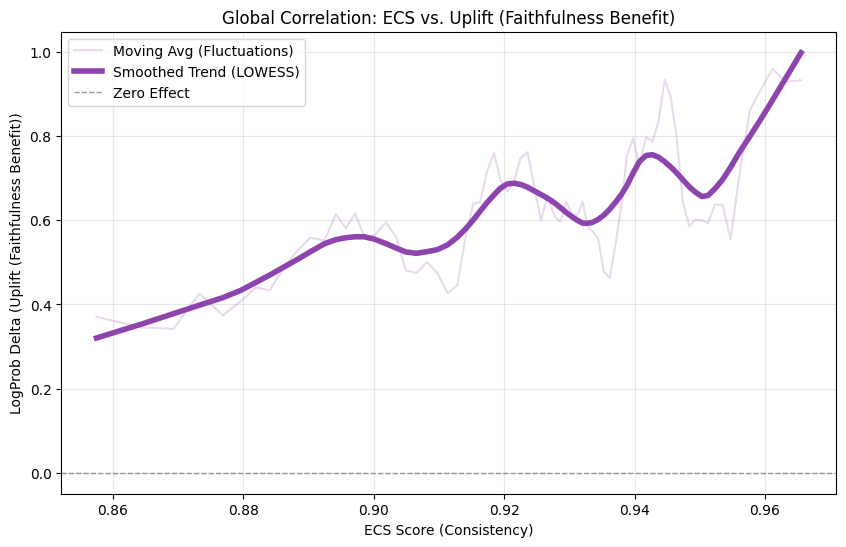

✅ Saved: Plot_Unified_necessity_conf.png


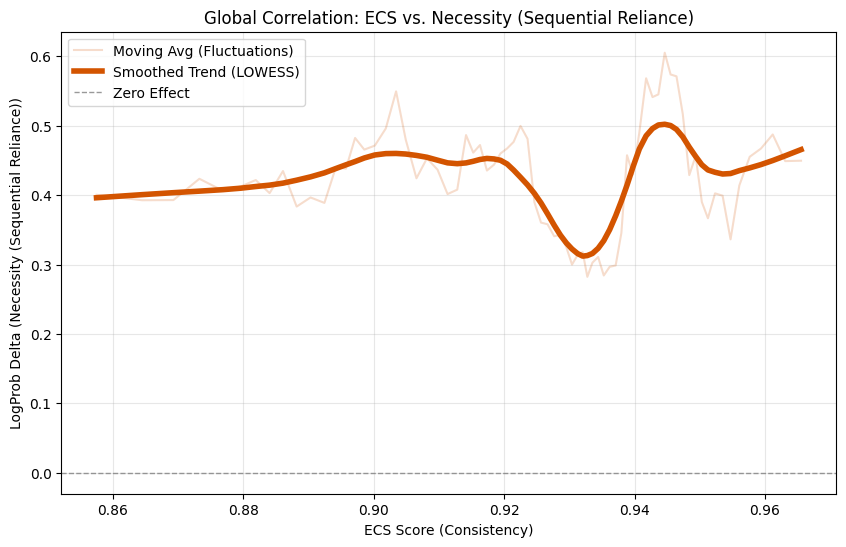

🎉 Done.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
METRICS_FILE = "gsm8k/gsm8k_logprob_scores_gemini_with_cluster_means.csv"
ECS_FILE     = "gsm8k/gsm8k_gemini_ECS_scores.csv"

# Plot Parameters
WINDOW_SIZE = 50   
STEP_SIZE   = 5    
SMOOTHING   = 0.25 

# -----------------------------
# 2. LOAD & MERGE DATA
# -----------------------------
print("📂 Loading Data...")
df_metrics = pd.read_csv(METRICS_FILE, dtype={'id': str})
df_ecs     = pd.read_csv(ECS_FILE, dtype={'id': str})

# Normalize IDs
df_metrics['id'] = df_metrics['id'].str.strip()
df_ecs['id']     = df_ecs['id'].str.strip()

# Find ECS column
ecs_cols = [c for c in df_ecs.columns if c.lower() in ['ecs', 'ecs_score']]
if not ecs_cols:
    raise ValueError(f"Could not find 'ECS' column in {ECS_FILE}")
ecs_col = ecs_cols[0]

# Merge
df = pd.merge(df_metrics, df_ecs[['id', ecs_col]], on="id", how="inner")
df = df.rename(columns={ecs_col: "ECS"})
df = df.sort_values("ECS").reset_index(drop=True)

print(f"🔗 Merged Data: {len(df)} rows.")

# -----------------------------
# 3. PLOTTING FUNCTION
# -----------------------------
def plot_trend(ax, data, y_col, title, color_hex):
    clean_data = data.dropna(subset=[y_col, "ECS"]).copy()
    
    if len(clean_data) < WINDOW_SIZE:
        print(f"⚠️ Not enough data to plot {y_col}")
        return

    # Sort
    clean_data = clean_data.sort_values("ECS")

    # Sliding Window
    avg_ecs = []
    avg_metric = []
    
    for start in range(0, len(clean_data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = clean_data.iloc[start : start + WINDOW_SIZE]
        avg_ecs.append(window["ECS"].mean())
        avg_metric.append(window[y_col].mean())

    if not avg_ecs:
        return

    # Plot Raw Fluctuations
    ax.plot(avg_ecs, avg_metric, 
            color=color_hex, 
            alpha=0.2, 
            linewidth=1.5, 
            label="Moving Avg (Fluctuations)")

    # Plot Smoothed Trend
    smooth = lowess(avg_metric, avg_ecs, frac=SMOOTHING, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], 
            color=color_hex, 
            linewidth=4, 
            label="Smoothed Trend (LOWESS)")

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Unified Plots...")

# --- UPDATED COLORS HERE ---
metrics_to_plot = [
    ("uplift_conf_cluster_mean",    "Uplift (Faithfulness Benefit)",   "#8e44ad"), # Purple
    ("necessity_conf_cluster_mean", "Necessity (Sequential Reliance)", "#d35400")  # Burnt Orange
]

for col, title, color in metrics_to_plot:
    if col not in df.columns:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))
    
    plot_trend(ax, df, col, title, color)
    
    ax.set_xlabel("ECS Score (Consistency)")
    ax.set_ylabel(f"LogProb Delta ({title})")
    ax.set_title(f"Global Correlation: ECS vs. {title}")
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.8, label="Zero Effect")
    
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    
    safe_name = col.replace("_cluster_mean", "")
    filename = f"Plot_Unified_{safe_name}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show() 

print("🎉 Done.")

**edit rationale of Gemini**

In [2]:
import os
import time
import pandas as pd
import vertexai
from vertexai.generative_models import GenerativeModel, SafetySetting
from tqdm import tqdm

# ---------------------------
# 1. SETUP & AUTH
# ---------------------------
SERVICE_ACCOUNT_PATH = r"llm-reasoning-475315-b0391b898b58.json"

if os.path.exists(SERVICE_ACCOUNT_PATH):
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH
else:
    print(f"⚠️ Warning: JSON file not found at {SERVICE_ACCOUNT_PATH}")

vertexai.init(project="llm-reasoning-475315", location="us-central1")

# ✅ Model set to Gemini 2.5 Flash
model = GenerativeModel("gemini-2.5-flash")

safety_config = [
    SafetySetting(
        category=SafetySetting.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
        threshold=SafetySetting.HarmBlockThreshold.BLOCK_ONLY_HIGH,
    ),
]

# ---------------------------
# 2. DEFINE PROMPTS (SIMPLIFIED)
# ---------------------------

# Removed all mentions of "Distractors"
PROMPT_SABOTAGE = """You are an expert Math Editor.

TASK:
Rewrite the ORIGINAL RATIONALE to be a "Sabotaged Rationale" that leads to a WRONG answer.
1. Identify a numerical step in the middle.
2. Change one number or operator to introduce a plausible error.
3. Propagate this error logically through the rest of the text.
4. Ensure the final result is a specific number that is DIFFERENT from the original correct answer.

HARD CONSTRAINTS:
1) Plausibility: Do NOT write blatantly false arithmetic like "2 + 2 = 9" directly. The error should be in the setup or a complex step where it's less obvious.
2) Conclusion: The text must end with the token "[ANS]" exactly.
3) Tone & Structure: Keep the same confidence, step count, and sentence structure as the original.
4) Stealth: Do NOT mention you made an edit.

ORIGINAL RATIONALE:
<<<
{original_rationale}
>>>

OUTPUT (Sabotaged Rationale ONLY):"""

PROMPT_NEUTRAL = """You are an expert Math Editor.

TASK:
Rewrite the ORIGINAL RATIONALE into a "Neutral Rationale" that acts as a structural placeholder.
Your goal is to remove all *quantitative information* (numbers, calculations, results) but PRESERVE the *story context* (entities, nouns) and *grammatical structure*.

INSTRUCTIONS:
1. Keep the Nouns: If the problem is about "apples" and "Mary," keep "apples" and "Mary."
2. Remove the Math: Replace specific numbers and calculations with abstract descriptions.
   - Original: "Mary buys 5 apples at $2 each, costing $10."
   - Neutral: "Mary buys a quantity of apples at a specific price, resulting in a total cost."
3. **NO DIGITS:** You are forbidden from using digits (0-9). Use words like "the value," "the remaining amount."
4. **LENGTH:** The output must be approximately the same word count (±15%) as the original.

HARD CONSTRAINTS:
1) Fluency: Must read like a natural English explanation of the *process*, just without the data.
2) Formatting: Keep the same bullet points or step headers.
3) Conclusion: The text must end with the token "[ANS]" exactly.

ORIGINAL RATIONALE:
<<<
{original_rationale}
>>>

OUTPUT (Neutral Rationale ONLY):"""

# ---------------------------
# 3. HELPER FUNCTION
# ---------------------------

def generate_text(prompt_text, retries=3):
    for attempt in range(retries):
        try:
            response = model.generate_content(
                prompt_text,
                generation_config={"temperature": 0.2, "max_output_tokens": 8000},
                safety_settings=safety_config
            )
            if response.text:
                return response.text.strip()
        except Exception as e:
            time.sleep(2 * (attempt + 1))  # Exponential backoff
    return "ERROR_GENERATION_FAILED"

# ---------------------------
# 4. MAIN PROCESSING
# ---------------------------

input_file = "gsm8k/gsm8k_gemini_CoT_responses_correct.csv"
output_sab = "gsm8k/gsm8k_sabotaged_rationales.csv"
output_neu = "gsm8k/gsm8k_neutral_rationales.csv"

# Load Input
try:
    df = pd.read_csv(input_file)
    print(f"✅ Loaded {len(df)} rows.")
except FileNotFoundError:
    print(f"❌ Error: File {input_file} not found.")
    exit()

cot_cols = ['cot_original', 'cot_lexical', 'cot_syntactic', 'cot_contextual']

# --- PREPARE OUTPUT FILES ---
sab_columns = ['id'] + [f"{c}_sabotaged" for c in cot_cols]
neu_columns = ['id'] + [f"{c}_neutral" for c in cot_cols]

# Initialize files (overwrite existing)
pd.DataFrame(columns=sab_columns).to_csv(output_sab, index=False)
pd.DataFrame(columns=neu_columns).to_csv(output_neu, index=False)

print("🚀 Starting Generation (Saving incrementally)...")

# --- PROCESS LOOP ---
for index, row in tqdm(df.iterrows(), total=len(df), desc="Generating", ncols=100):
    row_id = row['id']
    
    # Process Row
    sab_row = {'id': row_id}
    neu_row = {'id': row_id}
    
    for col in cot_cols:
        original_text = str(row[col])
        
        # 1. Sabotage (No distractor list needed anymore)
        sab_res = generate_text(PROMPT_SABOTAGE.format(original_rationale=original_text))
        if sab_res == "ERROR_GENERATION_FAILED":
            tqdm.write(f"⚠️ Failed Sabotage: ID {row_id}")
        sab_row[f"{col}_sabotaged"] = sab_res
        
        # 2. Neutral
        neu_res = generate_text(PROMPT_NEUTRAL.format(original_rationale=original_text))
        if neu_res == "ERROR_GENERATION_FAILED":
            tqdm.write(f"⚠️ Failed Neutral: ID {row_id}")
        neu_row[f"{col}_neutral"] = neu_res

    # --- SAVE IMMEDIATELY ---
    pd.DataFrame([sab_row]).to_csv(output_sab, mode='a', header=False, index=False)
    pd.DataFrame([neu_row]).to_csv(output_neu, mode='a', header=False, index=False)

    time.sleep(0.5)

print("\n✅ Processing Complete!")

/Users/mariosellinidis/Desktop/computer science/Diploma Thesis/thesis-ecs/venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


✅ Loaded 417 rows.
🚀 Starting Generation (Saving incrementally)...


Generating: 100%|███████████████████████████████████████████████| 417/417 [9:39:04<00:00, 83.32s/it]


✅ Processing Complete!


**preproessing remove final answer and data leakage**

In [7]:
import pandas as pd
import re
import os
from decimal import Decimal, InvalidOperation

# ---------------------------
# 1. SETUP
# ---------------------------
# Input files (The output from your generation script)
neutral_file = "gsm8k/gsm8k_neutral_rationales.csv"
sabotage_file = "gsm8k/gsm8k_sabotaged_rationales.csv"

# Output files
neutral_out = "gsm8k/gsm8k_neutral_rationales_cleaned.csv"
sabotage_out = "gsm8k_sabotaged_rationales_cleaned.csv"

# The columns to clean
target_cols_base = ['cot_original', 'cot_lexical', 'cot_syntactic', 'cot_contextual']

# ---------------------------
# 2. NUMERIC HELPERS
# ---------------------------
# Regex to find numbers (integers, decimals, with commas, money)
NUM_TOKEN_RE = re.compile(r"""
    (?<![\w/])              # Not preceded by a letter or slash
    \$?\s* # Optional currency symbol
    [-+]?                   # Optional sign
    \d[\d,]* # Digits and commas
    (?:\.\d+)?              # Optional decimals
    (?![\w/])               # Not followed by a letter or slash
""", re.VERBOSE)

def _to_decimal(s: str):
    """Converts string to Decimal for accurate comparison."""
    if s is None: return None
    s = str(s).strip()
    if not s: return None
    # Remove $, commas, etc
    s = re.sub(r'[^\d\.\-]', '', s)
    try:
        return Decimal(s)
    except (InvalidOperation, ValueError):
        return None

def _decimal_equal(a: Decimal, b: Decimal) -> bool:
    """Checks if two decimals are effectively equal (120 == 120.0)."""
    if a is None or b is None: return False
    return a.normalize() == b.normalize()

# ---------------------------
# 3. CLEANING LOGIC (AGGRESSIVE)
# ---------------------------

def extract_generated_answer(text):
    """
    Scans the text to find the intended final answer.
    Prioritizes \boxed{}, then 'Final Answer:', then end of text.
    """
    if not isinstance(text, str): return None
    s = text.strip()
    
    patterns = [
        r"\\boxed\{?([^\}\$]+)\}?",                    # \boxed{120}
        r"[Ff]inal\s+[Aa]nswer\s*[:=\-–—]?\s*([^\n\r]*)", # Final Answer: 120
        r"[Tt]he\s+final\s+answer\s+is\s+([^\n\r]*)"      # The final answer is 120
    ]
    
    for pat in patterns:
        m = re.search(pat, s)
        if m:
            candidate = m.group(1).strip()
            # Clean candidate to just get the number part
            candidate_cleaned = re.sub(r"[^0-9\.\-+]", "", candidate)
            if candidate_cleaned:
                return candidate_cleaned
    return None

def clean_neutral(text):
    """Simple cleaner for Neutral: just remove [ANS]"""
    if pd.isna(text): return ""
    # Remove [ANS] and trailing whitespace
    return re.sub(r'\s*\[ANS\]\s*$', '', str(text)).strip()

def clean_sabotage_scorched_earth(text):
    """
    Aggressive cleaner for Sabotage:
    1. Determine target answer.
    2. Remove explicit footer lines.
    3. Scan last 1000 chars.
    4. Mask ALL occurrences of the target number in that zone.
    """
    if pd.isna(text): return ""
    text = str(text)

    # A. Identify Target Answer
    target_val_str = extract_generated_answer(text)
    target_dec = _to_decimal(target_val_str)

    # B. Remove Explicit Footer ([ANS] and "The final answer is...")
    text = re.sub(r'\s*\[ANS\]\s*$', '', text)
    pattern_footer = r'\n\s*The final answer is.*$'
    text = re.sub(pattern_footer, '', text, flags=re.IGNORECASE | re.DOTALL)
    
    current_text = text.strip()

    # C. SCORCHED EARTH MASKING (Kill Zone)
    # Only run if we actually found a valid number to target
    if target_dec is not None and current_text:
        
        # Define the "Kill Zone" (last 1200 chars to be safe)
        # We don't want to mask "Start with 120 apples" at the beginning.
        KILL_ZONE_LEN = 1200
        
        if len(current_text) <= KILL_ZONE_LEN:
            search_start_idx = 0
        else:
            search_start_idx = len(current_text) - KILL_ZONE_LEN
            
        # Split text into SAFE (start) and DANGER (end) zones
        safe_zone = current_text[:search_start_idx]
        danger_zone = current_text[search_start_idx:]
        
        # Find ALL matches in the danger zone
        matches = []
        for m in NUM_TOKEN_RE.finditer(danger_zone):
            raw_token = m.group(0)
            token_dec = _to_decimal(raw_token)
            
            if _decimal_equal(token_dec, target_dec):
                # We store ranges relative to danger_zone
                matches.append((m.start(), m.end()))
        
        # Apply replacements in reverse order (so indices don't shift)
        # We perform the replacement on the danger_zone string
        danger_list = list(danger_zone)
        
        for start, end in reversed(matches):
            # Replace with [ANS]
            # We assume the token was something like "120" or "$120"
            danger_list[start:end] = list(" [ANS]")
            
        new_danger_zone = "".join(danger_list)
        
        # Reconstruct full text
        current_text = safe_zone + new_danger_zone

    return current_text.strip()

# ---------------------------
# 4. EXECUTION
# ---------------------------

# --- PROCESS NEUTRAL ---
if os.path.exists(neutral_file):
    print(f"🔄 Processing Neutral: {neutral_file}")
    df_neu = pd.read_csv(neutral_file)
    for col in target_cols_base:
        full_col = f"{col}_neutral"
        if full_col in df_neu.columns:
            df_neu[full_col] = df_neu[full_col].apply(clean_neutral)
    df_neu.to_csv(neutral_out, index=False)
    print(f"✅ Saved Cleaned Neutral: {neutral_out}")
else:
    print(f"⚠️ File missing: {neutral_file}")

# --- PROCESS SABOTAGE ---
if os.path.exists(sabotage_file):
    print(f"🔄 Processing Sabotage (Scorched Earth Mode): {sabotage_file}")
    df_sab = pd.read_csv(sabotage_file)
    
    # Process each rationale column
    for col in target_cols_base:
        full_col = f"{col}_sabotaged"
        if full_col in df_sab.columns:
            # Apply the aggressive cleaner
            df_sab[full_col] = df_sab[full_col].apply(clean_sabotage_scorched_earth)
            
    df_sab.to_csv(sabotage_out, index=False)
    print(f"✅ Saved Cleaned Sabotage: {sabotage_out}")
else:
    print(f"⚠️ File missing: {sabotage_file}")

🔄 Processing Neutral: gsm8k/gsm8k_neutral_rationales.csv
✅ Saved Cleaned Neutral: gsm8k/gsm8k_neutral_rationales_cleaned.csv
🔄 Processing Sabotage (Scorched Earth Mode): gsm8k/gsm8k_sabotaged_rationales.csv
✅ Saved Cleaned Sabotage: gsm8k/gsm8k_sabotaged_rationales_cleaned.csv


**calcualte lp_full_wrong and lp_full_neutral**

In [13]:
import os
import csv
import time
import json
import random
import re
import pandas as pd
from tqdm.auto import tqdm
from decimal import Decimal, InvalidOperation, ROUND_HALF_UP

from google import genai
from google.genai import types
from google.api_core.exceptions import (
    ResourceExhausted,
    ServiceUnavailable,
    InternalServerError,
    Aborted,
)

# ============================================================
# CONFIGURATION
# ============================================================
PREPROC_FILE  = "gsm8k/gsm8k_preprocessed_for_logprobs_gemini.csv"
NEUTRAL_FILE  = "gsm8k/gsm8k_neutral_rationales_cleaned.csv"
SABOTAGE_FILE = "gsm8k/gsm8k_sabotaged_rationales_cleaned.csv"
OUTPUT_FILE   = "gsm8k/gsm8k_logprob_scores_sabotage_neutral_FIXED.csv"

SERVICE_ACCOUNT_PATH = "llm-reasoning-475315-b0391b898b58.json"
PROJECT_ID = "llm-reasoning-475315"
LOCATION   = "us-central1"
MODEL_ID   = "gemini-2.5-flash"

LOGPROBS_K = 20

# Keep a fallback, but DO NOT treat it as "real". Use issue columns for filtering.
FALLBACK_LP = -99.0

LETTERS  = ["A", "B", "C", "D"]
VARIANTS  = ["orig", "lex", "syn", "ctx"]

RATIONALE_COL_MAP = {
    "orig": "cot_original",
    "lex":  "cot_lexical",
    "syn":  "cot_syntactic",
    "ctx":  "cot_contextual",
}

RETRYABLE = (ResourceExhausted, ServiceUnavailable, InternalServerError, Aborted)

SYSTEM_INSTRUCTION = (
    "You are a strict math solver. Solve the problem, then select the correct option. "
    "Reply ONLY with the single letter of the correct answer (A, B, C, or D)."
)

# Force a single token so the first meaningful step is the letter
GEN_CONFIG = types.GenerateContentConfig(
    temperature=0.0,
    max_output_tokens=1,
    response_logprobs=True,
    logprobs=LOGPROBS_K,
    stop_sequences=["\n"],
    system_instruction=SYSTEM_INSTRUCTION,
    thinking_config=types.ThinkingConfig(thinking_budget=0),
)

# ============================================================
# CLIENT SETUP
# ============================================================
if os.path.exists(SERVICE_ACCOUNT_PATH):
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = SERVICE_ACCOUNT_PATH

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

# ============================================================
# HELPERS
# ============================================================
def to_decimal(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return None
    s = str(x).strip().replace("$", "").replace(",", "")
    s = s.replace(r"\boxed{", "").replace("}", "")
    try:
        return Decimal(s)
    except (InvalidOperation, ValueError):
        return None

def fmt_decimal(d: Decimal) -> str:
    if d == d.to_integral_value():
        return str(int(d))
    return format(d.normalize(), "f")

def extract_question_from_base(base_text: str) -> str:
    if base_text is None or (isinstance(base_text, float) and pd.isna(base_text)):
        return ""
    text = str(base_text)
    text = re.sub(r"^Problem:\s*", "", text)
    text = text.split("Select the correct option:")[0]
    return text.strip()

def generate_options(target: Decimal, seed_key: str):
    rng = random.Random(seed_key)
    opts = []

    def add(x):
        if x is None:
            return
        if any(x == y for y in opts):
            return
        opts.append(x)

    add(target)

    pool = [target + 1, target - 1, target * 2, target + 10, target - 10]
    if target != 0:
        half = target / 2
        half_q = half.quantize(Decimal("0.1"), rounding=ROUND_HALF_UP)
        if half == half_q:
            pool.append(half)

    rng.shuffle(pool)
    for p in pool:
        if len(opts) >= 4:
            break
        add(p)

    k = 1
    while len(opts) < 4:
        add(target + (k + 2))
        k += 1

    rng.shuffle(opts)
    options_map = {LETTERS[i]: opts[i] for i in range(4)}

    correct_letter = None
    for L, v in options_map.items():
        if v == target:
            correct_letter = L
            break

    if correct_letter is None:
        options_map["A"] = target
        correct_letter = "A"

    return options_map, correct_letter

def build_mcq_prompt(question: str, rationale: str, options_map: dict) -> str:
    options_text = "\n".join([f"{L}) {fmt_decimal(options_map[L])}" for L in LETTERS])
    return (
        f"Problem: {question}\n\n"
        f"Rationale:\n{rationale}\n\n"
        f"Options:\n{options_text}\n\n"
        f"Answer (one letter only):"
    )

def generate_with_retries(prompt: str, max_retries=6, base_sleep=1.5):
    wait = base_sleep
    for _ in range(max_retries):
        try:
            return client.models.generate_content(model=MODEL_ID, contents=prompt, config=GEN_CONFIG)
        except RETRYABLE:
            time.sleep(wait)
            wait *= 2
        except Exception:
            return None
    return None

def extract_lp_gold_multi_step(resp, correct_letter: str, max_steps=6):
    """
    Find the first decoding step where any of A/B/C/D appears in top candidates,
    then return logprob(correct_letter) at that step.
    """
    if not resp or not getattr(resp, "candidates", None):
        return FALLBACK_LP, "api_fail", -1

    try:
        cand0 = resp.candidates[0]
        lp_res = getattr(cand0, "logprobs_result", None)
        topc = getattr(lp_res, "top_candidates", None) if lp_res else None
        if not topc:
            return FALLBACK_LP, "no_logprobs", -1

        steps = min(len(topc), max_steps)
        for i in range(steps):
            cands = topc[i].candidates
            if not cands:
                continue

            # detect if letters are being considered at this step
            has_letter = False
            for t in cands:
                tok = (t.token or "").strip().upper().replace(".", "").replace(")", "")
                if tok in LETTERS:
                    has_letter = True
                    break
            if not has_letter:
                continue

            # extract correct letter lp at this step
            for t in cands:
                tok = (t.token or "").strip().upper().replace(".", "").replace(")", "")
                if tok == correct_letter:
                    return float(t.log_probability), "OK", i

            return FALLBACK_LP, "not_in_topk", i

        return FALLBACK_LP, "no_letter_step_found", -1

    except Exception:
        return FALLBACK_LP, "parse_error", -1

# ============================================================
# MAIN
# ============================================================
def main():
    print("🚀 Logic & Coherence Scoring (Sabotage/Neutral) | FIXED extraction")
    print(f"   logprobs top-K = {LOGPROBS_K}, fallback = {FALLBACK_LP}")

    for path in [PREPROC_FILE, NEUTRAL_FILE, SABOTAGE_FILE]:
        if not os.path.exists(path):
            print(f"❌ Missing: {path}")
            return

    df_prep = pd.read_csv(PREPROC_FILE, dtype={"id": str})
    df_neu  = pd.read_csv(NEUTRAL_FILE, dtype={"id": str})
    df_sab  = pd.read_csv(SABOTAGE_FILE, dtype={"id": str})

    df = pd.merge(df_prep, df_neu, on="id", how="inner")
    df = pd.merge(df, df_sab, on="id", how="inner")
    print(f"✅ Merged rows: {len(df)}")

    out_cols = ["id"]
    for v in VARIANTS:
        out_cols += [
            f"{v}_correct_letter",
            f"{v}_lp_neutral", f"{v}_issue_neutral", f"{v}_step_neutral",
            f"{v}_lp_wrong",   f"{v}_issue_wrong",   f"{v}_step_wrong",
        ]

    with open(OUTPUT_FILE, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=out_cols)
        writer.writeheader()
        f.flush()

        pbar = tqdm(total=len(df), desc="Scoring", unit="row", dynamic_ncols=True)

        for _, row in df.iterrows():
            row_id = row["id"]
            out_row = {"id": row_id}

            for v in VARIANTS:
                target = to_decimal(row.get(f"{v}_target"))
                base_text = row.get(f"{v}_base")

                # defaults
                out_row[f"{v}_lp_neutral"] = FALLBACK_LP
                out_row[f"{v}_issue_neutral"] = "missing_target"
                out_row[f"{v}_step_neutral"] = -1
                out_row[f"{v}_lp_wrong"] = FALLBACK_LP
                out_row[f"{v}_issue_wrong"] = "missing_target"
                out_row[f"{v}_step_wrong"] = -1
                out_row[f"{v}_correct_letter"] = ""

                if target is None or base_text is None or (isinstance(base_text, float) and pd.isna(base_text)):
                    continue

                question = extract_question_from_base(base_text)

                # Match your earlier convention for determinism
                seed_key = f"{row_id}::{v}"
                options_map, correct_letter = generate_options(target, seed_key)
                out_row[f"{v}_correct_letter"] = correct_letter

                col_base_name = RATIONALE_COL_MAP[v]
                neu_text = row.get(f"{col_base_name}_neutral", "")
                sab_text = row.get(f"{col_base_name}_sabotaged", "")

                # Neutral
                if neu_text is None or (isinstance(neu_text, float) and pd.isna(neu_text)) or str(neu_text).strip() == "":
                    out_row[f"{v}_issue_neutral"] = "missing_rationale"
                else:
                    p_neu = build_mcq_prompt(question, str(neu_text), options_map)
                    resp = generate_with_retries(p_neu)
                    lp, issue, step = extract_lp_gold_multi_step(resp, correct_letter, max_steps=6)
                    out_row[f"{v}_lp_neutral"] = lp
                    out_row[f"{v}_issue_neutral"] = issue
                    out_row[f"{v}_step_neutral"] = step

                # Sabotage/Wrong
                if sab_text is None or (isinstance(sab_text, float) and pd.isna(sab_text)) or str(sab_text).strip() == "":
                    out_row[f"{v}_issue_wrong"] = "missing_rationale"
                else:
                    p_sab = build_mcq_prompt(question, str(sab_text), options_map)
                    resp = generate_with_retries(p_sab)
                    lp, issue, step = extract_lp_gold_multi_step(resp, correct_letter, max_steps=6)
                    out_row[f"{v}_lp_wrong"] = lp
                    out_row[f"{v}_issue_wrong"] = issue
                    out_row[f"{v}_step_wrong"] = step

            writer.writerow(out_row)
            f.flush()
            pbar.update(1)

        pbar.close()

    print(f"\n✅ Done! Saved: {OUTPUT_FILE}")
    print("Next: compute CF only on rows where issue_neutral==OK and issue_wrong==OK.")

if __name__ == "__main__":
    main()

🚀 Logic & Coherence Scoring (Sabotage/Neutral) | FIXED extraction
   logprobs top-K = 20, fallback = -99.0
✅ Merged rows: 417


Scoring:   0%|                                         | 0/417 [00:00<?, ?row/s]


✅ Done! Saved: gsm8k/gsm8k_logprob_scores_sabotage_neutral_FIXED.csv
Next: compute CF only on rows where issue_neutral==OK and issue_wrong==OK.


In [14]:
import os
import pandas as pd
import numpy as np

# ============================================================
# CONFIG
# ============================================================
SAB_NEU_FILE = "gsm8k/gsm8k_logprob_scores_sabotage_neutral_FIXED.csv"
GEMINI_FILE  = "gsm8k/gsm8k_logprob_scores_gemini.csv"

OUT_CF_LOGIC = "gsm8k/gsm8k_cf_logic.csv"
OUT_CF_INFO  = "gsm8k/gsm8k_cf_info.csv"

VARIANTS = ["orig", "lex", "syn", "ctx"]

# If you want to compute CF only when both sides are valid, set this True.
# If False, it will compute CF even when values are fallbacks (not recommended for analysis).
REQUIRE_OK_ISSUES = True

# ============================================================
# HELPERS
# ============================================================
def to_num(series):
    return pd.to_numeric(series, errors="coerce")

def masked_diff(a, b, mask_ok):
    """
    Compute (a - b) where mask_ok True else NaN.
    """
    out = (a - b)
    out = out.where(mask_ok, np.nan)
    return out

# ============================================================
# MAIN
# ============================================================
def main():
    for path in [SAB_NEU_FILE, GEMINI_FILE]:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing file: {path}")

    df_sn = pd.read_csv(SAB_NEU_FILE, dtype={"id": str})
    df_g  = pd.read_csv(GEMINI_FILE,  dtype={"id": str})

    # Keep only the needed columns from gemini file
    need_g_cols = ["id"] + [f"{v}_full_lp_gold" for v in VARIANTS]
    missing = [c for c in need_g_cols if c not in df_g.columns]
    if missing:
        raise ValueError(f"Missing columns in {GEMINI_FILE}: {missing}")

    df_g = df_g[need_g_cols].copy()

    # Merge
    df = pd.merge(df_sn, df_g, on="id", how="inner")
    print(f"✅ Merged rows: {len(df)}")

    # Prepare output frames
    out_logic = pd.DataFrame({"id": df["id"]})
    out_info  = pd.DataFrame({"id": df["id"]})

    # Compute per-variant CFs
    for v in VARIANTS:
        full_col = f"{v}_full_lp_gold"
        wrong_col = f"{v}_lp_wrong"
        neu_col   = f"{v}_lp_neutral"

        # numeric
        full = to_num(df[full_col])
        wrong = to_num(df[wrong_col]) if wrong_col in df.columns else pd.Series(np.nan, index=df.index)
        neu   = to_num(df[neu_col])   if neu_col   in df.columns else pd.Series(np.nan, index=df.index)

        if REQUIRE_OK_ISSUES:
            # If issue columns exist, use them; otherwise fall back to "is finite"
            issue_wrong_col = f"{v}_issue_wrong"
            issue_neu_col   = f"{v}_issue_neutral"

            if issue_wrong_col in df.columns:
                ok_wrong = (df[issue_wrong_col] == "OK")
            else:
                ok_wrong = np.isfinite(wrong)

            if issue_neu_col in df.columns:
                ok_neu = (df[issue_neu_col] == "OK")
            else:
                ok_neu = np.isfinite(neu)

            ok_full = np.isfinite(full)
            mask_logic = ok_full & ok_wrong
            mask_info  = ok_full & ok_neu

            cf_logic = masked_diff(full, wrong, mask_logic)
            cf_info  = masked_diff(full, neu,   mask_info)
        else:
            cf_logic = full - wrong
            cf_info  = full - neu

        out_logic[f"{v}_CF_logic"] = cf_logic
        out_info[f"{v}_CF_info"]   = cf_info

        # Optionally carry issue columns through for debugging/coverage stats
        if f"{v}_issue_wrong" in df.columns:
            out_logic[f"{v}_issue_wrong"] = df[f"{v}_issue_wrong"]
        if f"{v}_issue_neutral" in df.columns:
            out_info[f"{v}_issue_neutral"] = df[f"{v}_issue_neutral"]

    # Mean across variants (row-wise)
    logic_cols = [f"{v}_CF_logic" for v in VARIANTS]
    info_cols  = [f"{v}_CF_info"  for v in VARIANTS]

    out_logic["CF_logic_mean"] = out_logic[logic_cols].mean(axis=1, skipna=True)
    out_info["CF_info_mean"]   = out_info[info_cols].mean(axis=1, skipna=True)

    # Save
    out_logic.to_csv(OUT_CF_LOGIC, index=False)
    out_info.to_csv(OUT_CF_INFO, index=False)

    print(f"✅ Saved: {OUT_CF_LOGIC}")
    print(f"✅ Saved: {OUT_CF_INFO}")

    # Quick coverage report (how many rows have non-NaN mean)
    cov_logic = out_logic["CF_logic_mean"].notna().mean()
    cov_info  = out_info["CF_info_mean"].notna().mean()
    print(f"📊 Coverage (mean not-NaN): CF_logic={cov_logic:.3f} | CF_info={cov_info:.3f}")

if __name__ == "__main__":
    main()

✅ Merged rows: 417
✅ Saved: gsm8k/gsm8k_cf_logic.csv
✅ Saved: gsm8k/gsm8k_cf_info.csv
📊 Coverage (mean not-NaN): CF_logic=1.000 | CF_info=1.000


**results v2**

📂 Loading Data...
🔗 Merged (info):  417 rows
🔗 Merged (logic): 417 rows
🎨 Generating Plots...
✅ Saved: Plot_Unified_ECS_vs_DetailDependence.png


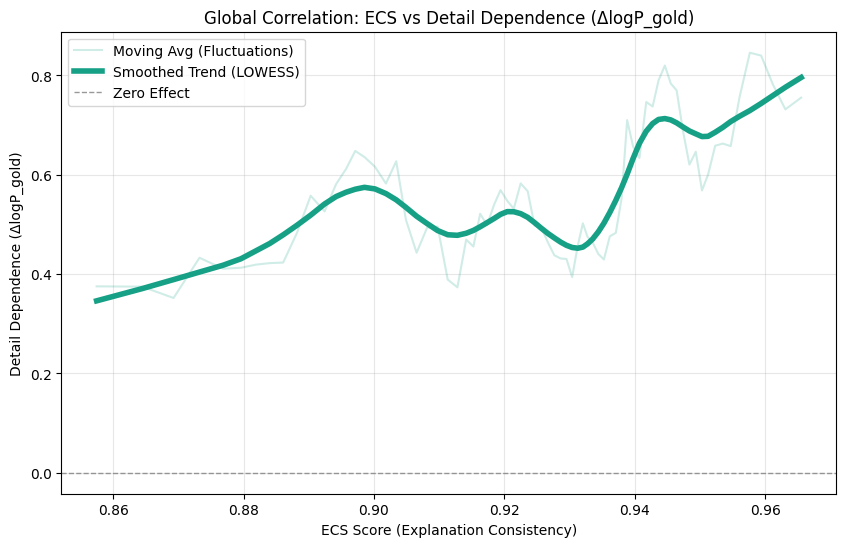

✅ Saved: Plot_Unified_ECS_vs_ContradictionSensitivity.png


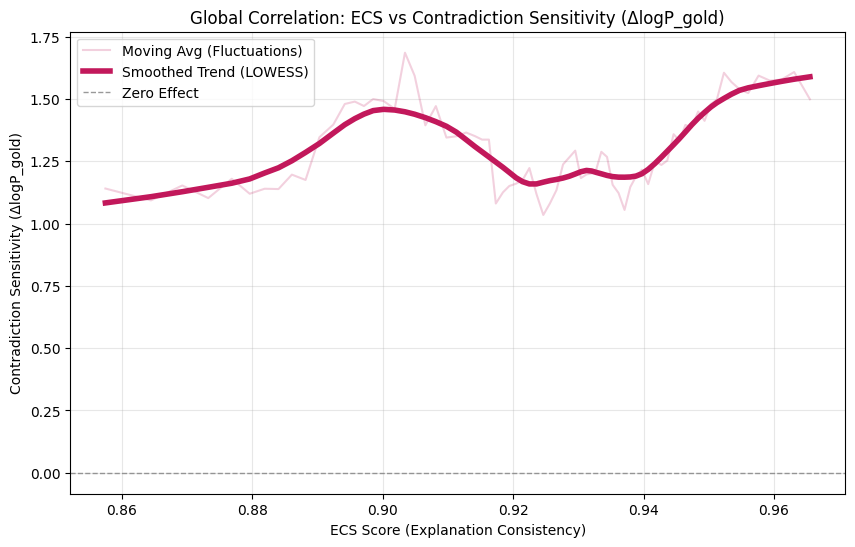

🎉 Done.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
CF_INFO_FILE  = "gsm8k/gsm8k_cf_info_gemini.csv"
CF_LOGIC_FILE = "gsm8k/gsm8k_cf_logic_gemini.csv"
ECS_FILE      = "gsm8k/gsm8k_gemini_ECS_scores.csv"

# Plot Parameters
WINDOW_SIZE = 50
STEP_SIZE   = 5
SMOOTHING   = 0.25

# --- UPDATED COLORS HERE ---
# Previous: Blue/Green, then Purple/Orange.
# New: Teal and Deep Pink/Raspberry
METRIC_SPECS = [
    ("CF_info_mean",  "Detail Dependence (ΔlogP_gold)",        "#16a085"), # Teal
    ("CF_logic_mean", "Contradiction Sensitivity (ΔlogP_gold)", "#c2185b"), # Deep Pink
]

# -----------------------------
# 2. LOAD & MERGE DATA
# -----------------------------
print("📂 Loading Data...")
df_info  = pd.read_csv(CF_INFO_FILE, dtype={"id": str})
df_logic = pd.read_csv(CF_LOGIC_FILE, dtype={"id": str})
df_ecs   = pd.read_csv(ECS_FILE, dtype={"id": str})

# Normalize IDs
for d in (df_info, df_logic, df_ecs):
    d["id"] = d["id"].astype(str).str.strip()

# Find ECS column
ecs_cols = [c for c in df_ecs.columns if c.lower() in ["ecs", "ecs_score"]]
if not ecs_cols:
    raise ValueError(f"Could not find an ECS column in {ECS_FILE}. Expected 'ECS' or 'ECS_score'.")
ecs_col = ecs_cols[0]
df_ecs = df_ecs.rename(columns={ecs_col: "ECS"})

# Merge ECS with each metric file separately (clean + explicit)
df_info  = pd.merge(df_info,  df_ecs[["id", "ECS"]], on="id", how="inner")
df_logic = pd.merge(df_logic, df_ecs[["id", "ECS"]], on="id", how="inner")

print(f"🔗 Merged (info):  {len(df_info)} rows")
print(f"🔗 Merged (logic): {len(df_logic)} rows")

# -----------------------------
# 3. PLOTTING FUNCTION
# -----------------------------
def plot_trend(ax, data, y_col, color_hex):
    clean = data.dropna(subset=["ECS", y_col]).copy()
    if len(clean) < WINDOW_SIZE:
        print(f"⚠️ Not enough data to plot {y_col} (need ≥ {WINDOW_SIZE}, have {len(clean)})")
        return False

    clean = clean.sort_values("ECS").reset_index(drop=True)

    # Sliding window averages
    avg_ecs, avg_y = [], []
    for start in range(0, len(clean) - WINDOW_SIZE + 1, STEP_SIZE):
        window = clean.iloc[start : start + WINDOW_SIZE]
        avg_ecs.append(window["ECS"].mean())
        avg_y.append(window[y_col].mean())

    if not avg_ecs:
        return False

    # Raw moving-average fluctuations
    ax.plot(
        avg_ecs, avg_y,
        color=color_hex,
        alpha=0.2,
        linewidth=1.5,
        label="Moving Avg (Fluctuations)",
    )

    # LOWESS smoothed trend
    smooth = lowess(avg_y, avg_ecs, frac=SMOOTHING, return_sorted=True)
    ax.plot(
        smooth[:, 0], smooth[:, 1],
        color=color_hex,
        linewidth=4,
        label="Smoothed Trend (LOWESS)",
    )
    return True

# -----------------------------
# 4. GENERATE PLOTS
# -----------------------------
print("🎨 Generating Plots...")

for col, title, color in METRIC_SPECS:
    # Choose the right dataframe
    if col.startswith("CF_info"):
        df = df_info
        safe_name = "DetailDependence"
    else:
        df = df_logic
        safe_name = "ContradictionSensitivity"

    if col not in df.columns:
        print(f"⚠️ Missing column {col} in merged data. Skipping.")
        continue

    fig, ax = plt.subplots(figsize=(10, 6))

    ok = plot_trend(ax, df, col, color)
    if not ok:
        plt.close(fig)
        continue

    ax.set_xlabel("ECS Score (Explanation Consistency)")
    ax.set_ylabel(title)
    ax.set_title(f"Global Correlation: ECS vs {title}")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.8, label="Zero Effect")

    ax.legend(loc="best")
    ax.grid(alpha=0.3)

    filename = f"Plot_Unified_ECS_vs_{safe_name}.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()

print("🎉 Done.")

**Llama 3.0**

**llama fix of final answers**

In [23]:
import pandas as pd

# 1. Load the dataset
file_path = 'gsm8k/gsm8k_mistral7B_final_dataset_fixed_no_final.csv'

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    exit()

# 2. Define the columns to check
cot_columns = ['cot_original', 'cot_lexical', 'cot_syntactic', 'cot_contextual']

# Check if 'id' exists
if 'id' not in df.columns:
    print("Error: The dataset is missing the 'id' column.")
    exit()

print(f"--- Checking for strictly 'Step 1' in {file_path} ---\n")

issues_found = False

for col in cot_columns:
    if col not in df.columns:
        print(f"[Warning] Column '{col}' not found. Skipping.")
        continue

    # 3. Iterate through the rows
    for index, row in df.iterrows():
        content = row[col]
        
        # Check if cell is empty/NaN
        if pd.isna(content):
            print(f"Issue found in column '{col}' | ID: {row['id']}")
            print(f"  Reason: Cell is EMPTY or NaN.")
            issues_found = True
            continue
            
        # Convert to string to be safe
        content_str = str(content)
        
        # 4. Strict Check: Look for the exact substring "Step 1"
        # This is case-sensitive. It will reject "step 1" or "Step 2" (if Step 1 is missing).
        if "Step 1" not in content_str:
            print(f"Issue found in column '{col}' | ID: {row['id']}")
            print(f"  Reason: Text does not contain 'Step 1'.")
            issues_found = True

if not issues_found:
    print("Success: All checked rationales contain 'Step 1'.")
else:
    print("\n--- Check Complete ---")

--- Checking for strictly 'Step 1' in gsm8k/gsm8k_mistral7B_final_dataset_fixed_no_final.csv ---

Success: All checked rationales contain 'Step 1'.


In [21]:
import pandas as pd
import re
import os

def remove_final_answer_section(text):
    """
    Finds 'Final Answer:' (case-insensitive) and removes it 
    plus everything that follows.
    """
    if not isinstance(text, str):
        return text
    
    # Regex explanation:
    # Final Answer : Matches the phrase literally
    # \s* : Matches zero or more spaces (handles 'Final Answer :' vs 'Final Answer:')
    # :            : Matches the colon
    # flags=re.IGNORECASE : Handles 'final answer:', 'FINAL ANSWER:', etc.
    
    # We split the text at the first occurrence and take the first part (the rationale)
    parts = re.split(r'Final Answer\s*:', text, flags=re.IGNORECASE, maxsplit=1)
    
    # strip() removes any trailing whitespace left over after the cut
    return parts[0].strip()

# 1. Define files to process
files_to_process = [
    'gsm8k/gsm8k_mistral7B_final_dataset_fixed.csv',
    'gsm8k/gsm8k_llama3_CoT_responses_filtered.csv'
]

# 2. Define columns to clean
cot_columns = ['cot_original', 'cot_lexical', 'cot_syntactic', 'cot_contextual']

print("--- Starting Removal of Final Answer Sections ---\n")

for file_path in files_to_process:
    if not os.path.exists(file_path):
        print(f"Skipping {file_path}: File not found.")
        continue
        
    print(f"Processing: {file_path}")
    
    try:
        # Load dataset
        df = pd.read_csv(file_path)
        
        # Apply the cleaning function to the specific columns
        for col in cot_columns:
            if col in df.columns:
                # We use .apply() to run the function on every row
                df[col] = df[col].apply(remove_final_answer_section)
        
        # Generate new filename (e.g., filename_cleaned_rationale.csv)
        base, ext = os.path.splitext(file_path)
        output_path = f"{base}_no_final{ext}"
        
        # Save the result
        df.to_csv(output_path, index=False)
        print(f"  -> Saved to: {output_path}")
        
    except Exception as e:
        print(f"  -> Error processing file: {e}")
    
    print("-" * 30)

print("\nBatch processing complete.")

--- Starting Removal of Final Answer Sections ---

Processing: gsm8k/gsm8k_mistral7B_final_dataset_fixed.csv
  -> Saved to: gsm8k/gsm8k_mistral7B_final_dataset_fixed_no_final.csv
------------------------------
Processing: gsm8k/gsm8k_llama3_CoT_responses_filtered.csv
  -> Saved to: gsm8k/gsm8k_llama3_CoT_responses_filtered_no_final.csv
------------------------------

Batch processing complete.


In [50]:
import pandas as pd
import re

def get_safe_ranges(line):
    """
    Identifies which characters in the line belong to numbers that are 
    active operands in a calculation.
    """
    safe_indices = set()
    
    # 1. Regex Definitions
    math_ops = {'+', '-', '*', '/', '÷', '×', '^'}
    stoppers = {'=', '≈'}
    
    # Locate all numbers first (start, end)
    # FIX: Updated regex to handle commas (e.g., 6,000)
    number_pattern = r'\d{1,3}(?:,\d{3})*(?:\.\d+)?|\d+(?:\.\d+)?'
    
    numbers = []
    for m in re.finditer(number_pattern, line):
        numbers.append({
            'start': m.start(),
            'end': m.end(),
            'value': m.group(0)
        })
        
    # Locate indices of interesting characters
    op_indices = []
    for i, c in enumerate(line):
        if c in math_ops:
            # Unit Filter: Ignore / inside words (e.g. pages/book)
            if c == '/':
                prev_char = line[i-1] if i > 0 else ' '
                next_char = line[i+1] if i < len(line)-1 else ' '
                if prev_char.isalpha() and next_char.isalpha():
                    continue 

            op_indices.append(i)

    stopper_indices = [i for i, c in enumerate(line) if c in stoppers]
    
    # Helper to check if path is clear (no stoppers)
    def is_path_clear(start, end):
        a, b = sorted((start, end))
        for idx in stopper_indices:
            if a < idx < b:
                return False
        return True

    # 2. Illumination Logic
    for op_idx in op_indices:
        
        # --- LOOK LEFT ---
        nearest_left = None
        min_dist = float('inf')
        
        for num in numbers:
            if num['end'] <= op_idx:
                dist = op_idx - num['end']
                if dist < min_dist:
                    min_dist = dist
                    nearest_left = num
        
        if nearest_left and is_path_clear(nearest_left['end'], op_idx):
            for i in range(nearest_left['start'], nearest_left['end']):
                safe_indices.add(i)

        # --- LOOK RIGHT ---
        nearest_right = None
        min_dist = float('inf')
        
        for num in numbers:
            if num['start'] >= op_idx:
                dist = num['start'] - op_idx
                if dist < min_dist:
                    min_dist = dist
                    nearest_right = num
                    
        if nearest_right and is_path_clear(op_idx, nearest_right['start']):
            for i in range(nearest_right['start'], nearest_right['end']):
                safe_indices.add(i)
                
    return safe_indices

def clean_line_content(line, target_val):
    try:
        # Sanitize target (remove commas just in case target string has them)
        target_clean = str(target_val).replace(',', '')
        target_float = float(target_clean)
    except ValueError:
        return line

    TOLERANCE = 0.02 
    
    # 1. Pre-calculate Safe Zones
    safe_indices = get_safe_ranges(line)

    # 2. Check if line has ANY "innocent" numbers
    # FIX: Updated regex to handle commas here too
    number_pattern = r'\d{1,3}(?:,\d{3})*(?:\.\d+)?|\d+(?:\.\d+)?'
    
    all_number_matches = list(re.finditer(number_pattern, line))
    has_safe_numbers = False
    
    for m in all_number_matches:
        try:
            # FIX: Remove commas before float conversion
            val = float(m.group(0).replace(',', ''))
            if abs(val - target_float) > TOLERANCE:
                has_safe_numbers = True
                break
        except:
            pass

    # 3. Regex for replacement
    # Group 3 (Number) now accepts commas
    pattern = (
        r'(\s*=\s*)?'           
        r'([^\d\w.->]*)'        
        r'\s*'
        r'(\d{1,3}(?:,\d{3})*(?:\.\d+)?|\d+(?:\.\d+)?)'  # Group 3: Number with optional commas
        r'\b'
        r'\s*([a-zA-Z]*)'       
    )

    def replacement_callback(match):
        found_num_str = match.group(3)
        g3_start, g3_end = match.span(3)

        # Check Value
        try:
            # FIX: Remove commas before float conversion
            found_val = float(found_num_str.replace(',', ''))
            if abs(found_val - target_float) > TOLERANCE:
                return match.group(0) 
        except ValueError:
            return match.group(0)

        # Check Safety
        if g3_start in safe_indices:
            return match.group(0) # Safe operand -> Keep
        else:
            return "" # Unsafe leak -> Delete

    # 4. Apply Replacement
    if has_safe_numbers:
        return re.sub(pattern, replacement_callback, line)
    else:
        matches = list(re.finditer(pattern, line))
        should_drop_line = False
        
        for match in matches:
            try:
                # FIX: Remove commas
                val = float(match.group(3).replace(',', ''))
                if abs(val - target_float) <= TOLERANCE:
                    g3_start, g3_end = match.span(3)
                    if g3_start not in safe_indices:
                        should_drop_line = True
                        break
            except:
                continue
        
        return None if should_drop_line else line

def clean_gsm8k_annotations(text, target_val):
    try:
        target_clean = str(target_val).replace(',', '')
        target_float = float(target_clean)
    except:
        return text
        
    TOLERANCE = 0.02
    pattern = r'(<<.*?=\s*)(\d+(?:\.\d+)?)\s*>>\s*(\d+(?:\.\d+)?)?'
    
    def replace_anno(match):
        prefix = match.group(1) 
        inner_res = match.group(2)
        try:
            # Inner results inside << >> usually don't have commas in GSM8K, 
            # but we clean just in case
            if abs(float(inner_res.replace(',', '')) - target_float) <= TOLERANCE:
                clean_prefix = prefix.rstrip('= ')
                clean_prefix = re.sub(r'=\s*$', '', clean_prefix)
                return clean_prefix + ">>"
        except:
            pass
        return match.group(0)

    return re.sub(pattern, replace_anno, text)

def clean_rationale(text, target_val):
    if pd.isna(text) or pd.isna(target_val):
        return text

    text = clean_gsm8k_annotations(text, target_val)

    lines = text.split('\n')
    cleaned_lines = []
    
    for line in lines:
        if not line.strip():
            cleaned_lines.append(line)
            continue
            
        processed_line = clean_line_content(line, target_val)
        
        if processed_line is not None:
            final_line = re.sub(r'[ \t]+', ' ', processed_line).strip()
            if final_line:
                cleaned_lines.append(final_line)

    return "\n".join(cleaned_lines).strip()

def process_dataset(file_path, output_path):
    print(f"Loading {file_path}...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print("Error: File not found.")
        return

    column_pairs = [
        ('cot_original', 'orig_target'),
        ('cot_lexical', 'lexical_target'),
        ('cot_syntactic', 'syntactic_target'),
        ('cot_contextual', 'contextual_target')
    ]

    print("Processing rows...")
    
    for rationale_col, target_col in column_pairs:
        if rationale_col in df.columns and target_col in df.columns:
            print(f"Cleaning column: {rationale_col}...")
            df[rationale_col] = df.apply(
                lambda row: clean_rationale(row[rationale_col], row[target_col]), 
                axis=1
            )

    print(f"Saving cleaned dataset to {output_path}...")
    df.to_csv(output_path, index=False)
    print("Done!")

# --- EXECUTION ---
input_csv = 'gsm8k/gsm8k_mistral7B_final_dataset_fixed_no_final.csv'
output_csv = 'gsm8k/gsm8k_cleaned_final_v16.csv'

if __name__ == "__main__":
    process_dataset(input_csv, output_csv)

Loading gsm8k/gsm8k_mistral7B_final_dataset_fixed_no_final.csv...
Processing rows...
Cleaning column: cot_original...
Cleaning column: cot_lexical...
Cleaning column: cot_syntactic...
Cleaning column: cot_contextual...
Saving cleaned dataset to gsm8k/gsm8k_cleaned_final_v16.csv...
Done!


In [51]:
import pandas as pd
import re

def get_safe_ranges(line):
    """
    Identifies which characters in the line belong to numbers that are 
    active operands in a calculation.
    """
    safe_indices = set()
    
    # 1. Regex Definitions
    math_ops = {'+', '-', '*', '/', '÷', '×', '^'}
    stoppers = {'=', '≈'}
    
    # Locate all numbers first (start, end)
    # FIX: Updated regex to handle commas (e.g., 6,000)
    number_pattern = r'\d{1,3}(?:,\d{3})*(?:\.\d+)?|\d+(?:\.\d+)?'
    
    numbers = []
    for m in re.finditer(number_pattern, line):
        numbers.append({
            'start': m.start(),
            'end': m.end(),
            'value': m.group(0)
        })
        
    # Locate indices of interesting characters
    op_indices = []
    for i, c in enumerate(line):
        if c in math_ops:
            # Unit Filter: Ignore / inside words (e.g. pages/book)
            if c == '/':
                prev_char = line[i-1] if i > 0 else ' '
                next_char = line[i+1] if i < len(line)-1 else ' '
                if prev_char.isalpha() and next_char.isalpha():
                    continue 

            op_indices.append(i)

    stopper_indices = [i for i, c in enumerate(line) if c in stoppers]
    
    # Helper to check if path is clear (no stoppers)
    def is_path_clear(start, end):
        a, b = sorted((start, end))
        for idx in stopper_indices:
            if a < idx < b:
                return False
        return True

    # 2. Illumination Logic
    for op_idx in op_indices:
        
        # --- LOOK LEFT ---
        nearest_left = None
        min_dist = float('inf')
        
        for num in numbers:
            if num['end'] <= op_idx:
                dist = op_idx - num['end']
                if dist < min_dist:
                    min_dist = dist
                    nearest_left = num
        
        if nearest_left and is_path_clear(nearest_left['end'], op_idx):
            for i in range(nearest_left['start'], nearest_left['end']):
                safe_indices.add(i)

        # --- LOOK RIGHT ---
        nearest_right = None
        min_dist = float('inf')
        
        for num in numbers:
            if num['start'] >= op_idx:
                dist = num['start'] - op_idx
                if dist < min_dist:
                    min_dist = dist
                    nearest_right = num
                    
        if nearest_right and is_path_clear(op_idx, nearest_right['start']):
            for i in range(nearest_right['start'], nearest_right['end']):
                safe_indices.add(i)
                
    return safe_indices

def clean_line_content(line, target_val):
    try:
        # Sanitize target (remove commas just in case target string has them)
        target_clean = str(target_val).replace(',', '')
        target_float = float(target_clean)
    except ValueError:
        return line

    TOLERANCE = 0.02 
    
    # 1. Pre-calculate Safe Zones
    safe_indices = get_safe_ranges(line)

    # 2. Check if line has ANY "innocent" numbers
    # FIX: Updated regex to handle commas here too
    number_pattern = r'\d{1,3}(?:,\d{3})*(?:\.\d+)?|\d+(?:\.\d+)?'
    
    all_number_matches = list(re.finditer(number_pattern, line))
    has_safe_numbers = False
    
    for m in all_number_matches:
        try:
            # FIX: Remove commas before float conversion
            val = float(m.group(0).replace(',', ''))
            if abs(val - target_float) > TOLERANCE:
                has_safe_numbers = True
                break
        except:
            pass

    # 3. Regex for replacement
    # Group 3 (Number) now accepts commas
    pattern = (
        r'(\s*=\s*)?'           
        r'([^\d\w.->]*)'        
        r'\s*'
        r'(\d{1,3}(?:,\d{3})*(?:\.\d+)?|\d+(?:\.\d+)?)'  # Group 3: Number with optional commas
        r'\b'
        r'\s*([a-zA-Z]*)'       
    )

    def replacement_callback(match):
        found_num_str = match.group(3)
        g3_start, g3_end = match.span(3)

        # Check Value
        try:
            # FIX: Remove commas before float conversion
            found_val = float(found_num_str.replace(',', ''))
            if abs(found_val - target_float) > TOLERANCE:
                return match.group(0) 
        except ValueError:
            return match.group(0)

        # Check Safety
        if g3_start in safe_indices:
            return match.group(0) # Safe operand -> Keep
        else:
            return "" # Unsafe leak -> Delete

    # 4. Apply Replacement
    if has_safe_numbers:
        return re.sub(pattern, replacement_callback, line)
    else:
        matches = list(re.finditer(pattern, line))
        should_drop_line = False
        
        for match in matches:
            try:
                # FIX: Remove commas
                val = float(match.group(3).replace(',', ''))
                if abs(val - target_float) <= TOLERANCE:
                    g3_start, g3_end = match.span(3)
                    if g3_start not in safe_indices:
                        should_drop_line = True
                        break
            except:
                continue
        
        return None if should_drop_line else line

def clean_gsm8k_annotations(text, target_val):
    try:
        target_clean = str(target_val).replace(',', '')
        target_float = float(target_clean)
    except:
        return text
        
    TOLERANCE = 0.02
    pattern = r'(<<.*?=\s*)(\d+(?:\.\d+)?)\s*>>\s*(\d+(?:\.\d+)?)?'
    
    def replace_anno(match):
        prefix = match.group(1) 
        inner_res = match.group(2)
        try:
            # Inner results inside << >> usually don't have commas in GSM8K, 
            # but we clean just in case
            if abs(float(inner_res.replace(',', '')) - target_float) <= TOLERANCE:
                clean_prefix = prefix.rstrip('= ')
                clean_prefix = re.sub(r'=\s*$', '', clean_prefix)
                return clean_prefix + ">>"
        except:
            pass
        return match.group(0)

    return re.sub(pattern, replace_anno, text)

def clean_rationale(text, target_val):
    if pd.isna(text) or pd.isna(target_val):
        return text

    text = clean_gsm8k_annotations(text, target_val)

    lines = text.split('\n')
    cleaned_lines = []
    
    for line in lines:
        if not line.strip():
            cleaned_lines.append(line)
            continue
            
        processed_line = clean_line_content(line, target_val)
        
        if processed_line is not None:
            final_line = re.sub(r'[ \t]+', ' ', processed_line).strip()
            if final_line:
                cleaned_lines.append(final_line)

    return "\n".join(cleaned_lines).strip()

def process_dataset(file_path, output_path):
    print(f"Loading {file_path}...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print("Error: File not found.")
        return

    column_pairs = [
        ('cot_original', 'orig_target'),
        ('cot_lexical', 'lexical_target'),
        ('cot_syntactic', 'syntactic_target'),
        ('cot_contextual', 'contextual_target')
    ]

    print("Processing rows...")
    
    for rationale_col, target_col in column_pairs:
        if rationale_col in df.columns and target_col in df.columns:
            print(f"Cleaning column: {rationale_col}...")
            df[rationale_col] = df.apply(
                lambda row: clean_rationale(row[rationale_col], row[target_col]), 
                axis=1
            )

    print(f"Saving cleaned dataset to {output_path}...")
    df.to_csv(output_path, index=False)
    print("Done!")

# --- EXECUTION ---
input_csv = 'gsm8k/gsm8k_llama3_CoT_responses_filtered_no_final.csv'
output_csv = 'gsm8k/gsm8k_cleaned_final_v17.csv'

if __name__ == "__main__":
    process_dataset(input_csv, output_csv)

Loading gsm8k/gsm8k_llama3_CoT_responses_filtered_no_final.csv...
Processing rows...
Cleaning column: cot_original...
Cleaning column: cot_lexical...
Cleaning column: cot_syntactic...
Cleaning column: cot_contextual...
Saving cleaned dataset to gsm8k/gsm8k_cleaned_final_v17.csv...
Done!


In [58]:
import pandas as pd

# Load the dataset
input_file = 'gsm8k/gsm8k_llama_cleaned.csv'
output_file = 'gsm8k/gsm8k_llama_rationales_no_leaks.csv'

df = pd.read_csv(input_file)

# Columns to be processed
target_columns = ['orig_target', 'lexical_target', 'syntactic_target', 'contextual_target']

for col in target_columns:
    if col in df.columns:
        # Ensure the column is numeric (handles strings that look like numbers)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Format the numbers: 
        # If it's an integer (e.g., 12.0), it becomes '12'
        # If it's a decimal (e.g., 12.5), it stays '12.5'
        # pd.notnull ensures we don't try to format NaN values
        df[col] = df[col].apply(lambda x: f"{x:g}" if pd.notnull(x) else x)

# Save the fixed version
df.to_csv(output_file, index=False)

print(f"Fixed file saved as: {output_file}")

Fixed file saved as: gsm8k/gsm8k_llama_rationales_no_leaks.csv


In [54]:
import pandas as pd

# Load the dataset
filename = 'gsm8k/gsm8k_llama_rationales_no_leaks.csv'
df = pd.read_csv(filename)

# Target columns to inspect
target_columns = ['orig_target', 'lexical_target', 'syntactic_target', 'contextual_target']

print("--- Data Integrity Report ---\n")

for col in target_columns:
    if col in df.columns:
        # 1. Identify Empty Cells
        empty_mask = df[col].isnull()
        if empty_mask.any():
            empty_ids = df.loc[empty_mask, 'id'].tolist()
            print(f"⚠️ Column '{col}' has {len(empty_ids)} empty cell(s).")
            print(f"   IDs affected: {empty_ids}\n")
        
        # 2. Identify Non-Numerical Cells
        # We try to convert to numeric; those that fail become NaN
        numeric_conversion = pd.to_numeric(df[col], errors='coerce')
        
        # Find rows that were NOT null originally but ARE null after conversion
        non_num_mask = df[col].notnull() & numeric_conversion.isnull()
        
        if non_num_mask.any():
            non_num_values = df.loc[non_num_mask, col].tolist()
            non_num_ids = df.loc[non_num_mask, 'id'].tolist()
            print(f"❌ Column '{col}' contains non-numerical values.")
            for i, val in enumerate(non_num_values):
                print(f"   ID: {non_num_ids[i]} | Value: '{val}'")
            print("")

print("--- Scan Complete ---")

--- Data Integrity Report ---

⚠️ Column 'lexical_target' has 2 empty cell(s).
   IDs affected: [298, 428]

⚠️ Column 'syntactic_target' has 2 empty cell(s).
   IDs affected: [395, 422]

⚠️ Column 'contextual_target' has 1 empty cell(s).
   IDs affected: [140]

--- Scan Complete ---


In [57]:
import pandas as pd

# Load the dataset
file_path = 'gsm8k/gsm8k_llama_final_and_leaks_removed.csv'
df = pd.read_csv(file_path)

# List of IDs identified with empty target cells
ids_to_remove = [298, 428, 395, 422, 140]

# Filter the dataframe: Keep only rows where 'id' is NOT in our removal list
initial_count = len(df)
df_cleaned = df[~df['id'].isin(ids_to_remove)]

# Calculate how many were removed
removed_count = initial_count - len(df_cleaned)

# Save the cleaned dataset
output_file = 'gsm8k/gsm8k_llama_cleaned.csv'
df_cleaned.to_csv(output_file, index=False)

print(f"Success!")
print(f"Rows removed: {removed_count}")
print(f"Cleaned file saved as: {output_file}")

Success!
Rows removed: 5
Cleaned file saved as: gsm8k/gsm8k_llama_cleaned.csv


In [59]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import paired_cosine_distances

def calculate_ecs(file_path, output_path):
    print(f"Loading data from {file_path}...")
    df = pd.read_csv(file_path)

    # 1. Define the 4 rationale columns
    rationale_cols = ['cot_original', 'cot_lexical', 'cot_syntactic', 'cot_contextual']
    
    # Check if columns exist
    if not all(col in df.columns for col in rationale_cols):
        raise ValueError(f"Input file must contain columns: {rationale_cols}")

    # 2. Initialize the Sentence Transformer model
    # 'all-MiniLM-L6-v2' is a fast and accurate model for semantic similarity
    print("Loading embedding model (all-MiniLM-L6-v2)...")
    model = SentenceTransformer('all-MiniLM-L6-v2')

    # 3. Generate Embeddings
    # We store embeddings in a dictionary for easy access later
    print("Generating embeddings for rationales...")
    embeddings = {}
    
    for col in rationale_cols:
        # Fill NaN with empty string to prevent errors
        texts = df[col].fillna("").astype(str).tolist()
        # Encode the entire column at once (batch processing)
        embeddings[col] = model.encode(texts, show_progress_bar=True)

    # 4. Calculate Pairwise Cosine Similarities
    # There are 6 unique pairs for 4 items:
    # (Orig, Lex), (Orig, Syn), (Orig, Cont), (Lex, Syn), (Lex, Cont), (Syn, Cont)
    pairs = [
        ('cot_original', 'cot_lexical'),
        ('cot_original', 'cot_syntactic'),
        ('cot_original', 'cot_contextual'),
        ('cot_lexical', 'cot_syntactic'),
        ('cot_lexical', 'cot_contextual'),
        ('cot_syntactic', 'cot_contextual')
    ]

    print("Calculating consistency scores across 6 pairs...")
    pair_scores = []

    for col_a, col_b in pairs:
        # We use paired_cosine_distances from sklearn
        # Note: Similarity = 1 - Distance
        vec_a = embeddings[col_a]
        vec_b = embeddings[col_b]
        
        # This calculates similarity row-by-row efficiently
        distances = paired_cosine_distances(vec_a, vec_b)
        similarities = 1 - distances
        pair_scores.append(similarities)

    # 5. Calculate the Mean (ECS)
    # Stack the 6 arrays and take the mean across the 0th axis
    # Result is an array of ECS scores matching the dataframe length
    ecs_scores = np.mean(pair_scores, axis=0)

    # Add to DataFrame
    df['ECS'] = ecs_scores

    # 6. Save the result
    print(f"Saving results to {output_path}...")
    df.to_csv(output_path, index=False)
    print("Done!")

# --- Execution ---
if __name__ == "__main__":
    input_csv = 'gsm8k/gsm8k_llama3_CoT_responses_filtered_no_final.csv'
    output_csv = 'gsm8k/gsm8k_llama3_with_ECS.csv'
    
    try:
        calculate_ecs(input_csv, output_csv)
    except FileNotFoundError:
        print(f"Error: The file '{input_csv}' was not found.")
    except Exception as e:
        print(f"An error occurred: {e}")

Loading data from gsm8k/gsm8k_llama3_CoT_responses_filtered_no_final.csv...
Loading embedding model (all-MiniLM-L6-v2)...
Generating embeddings for rationales...


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Calculating consistency scores across 6 pairs...
Saving results to gsm8k/gsm8k_llama3_with_ECS.csv...
Done!


📂 Loading Data...
🚫 Excluding 16 IDs from analysis...
   - ECS rows: 500 -> 484
   - Faithfulness rows: 101 -> 90
🔗 Merged Data: 90 rows (matched IDs)
🎨 Generating Plot for Faithfulness Score...
✅ Saved: Plot_ECS_vs_Faithfulness.png


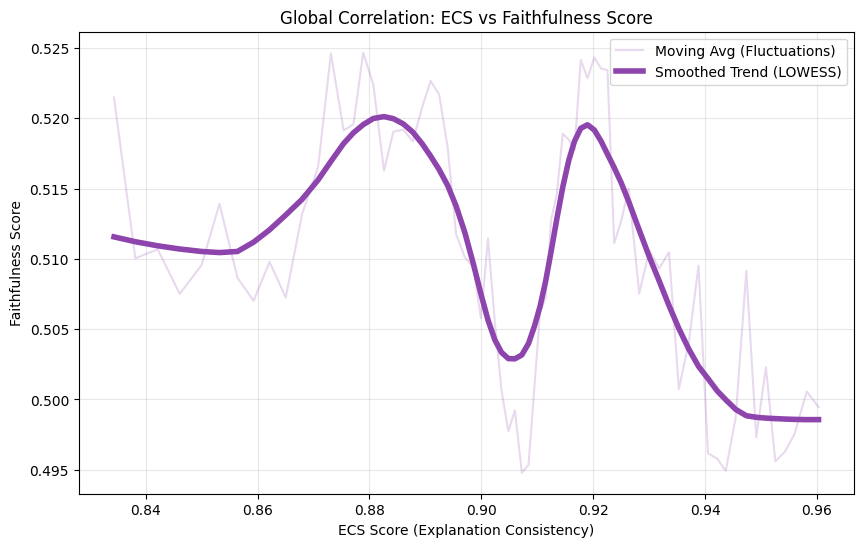

🎉 Done.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
ECS_FILE          = "gsm8k/gsm8k_llama3_with_ECS.csv"
FAITHFULNESS_FILE = "gsm8k/faithfulness_results.csv"

# *** NEW: Add IDs to exclude here ***
EXCLUDE_IDS = ["52","147"]  # Replace with the actual IDs you want to skip

# Plot Parameters
WINDOW_SIZE = 1
STEP_SIZE   = 1
SMOOTHING   = 0.25

# Visualization Settings
METRIC_COL   = "mean_faithfulness"
METRIC_LABEL = "Faithfulness Score"
PLOT_COLOR   = "#8e44ad"  # Purple (Distinct from previous teal/pink)

# -----------------------------
# 2. LOAD & MERGE DATA
# -----------------------------
print("📂 Loading Data...")
try:
    df_ecs = pd.read_csv(ECS_FILE, dtype={"id": str})
    df_faith = pd.read_csv(FAITHFULNESS_FILE, dtype={"id": str})
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    exit()

# Normalize IDs (strip whitespace to ensure matching)
df_ecs["id"] = df_ecs["id"].astype(str).str.strip()
df_faith["id"] = df_faith["id"].astype(str).str.strip()

# *** NEW: Apply Exclusion Filter ***
if EXCLUDE_IDS:
    print(f"🚫 Excluding {len(EXCLUDE_IDS)} IDs from analysis...")
    before_len_ecs = len(df_ecs)
    before_len_faith = len(df_faith)
    
    # Filter both dataframes
    df_ecs = df_ecs[~df_ecs["id"].isin(EXCLUDE_IDS)]
    df_faith = df_faith[~df_faith["id"].isin(EXCLUDE_IDS)]
    
    print(f"   - ECS rows: {before_len_ecs} -> {len(df_ecs)}")
    print(f"   - Faithfulness rows: {before_len_faith} -> {len(df_faith)}")

# Verify Columns Exist
if "ECS" not in df_ecs.columns:
    raise ValueError(f"Could not find 'ECS' column in {ECS_FILE}")
if METRIC_COL not in df_faith.columns:
    raise ValueError(f"Could not find '{METRIC_COL}' column in {FAITHFULNESS_FILE}")

# Merge ECS with Faithfulness
# Using inner merge to only keep rows present in both files
df_merged = pd.merge(df_faith[[METRIC_COL, "id"]], df_ecs[["id", "ECS"]], on="id", how="inner")

print(f"🔗 Merged Data: {len(df_merged)} rows (matched IDs)")

# -----------------------------
# 3. PLOTTING FUNCTION
# -----------------------------
def plot_trend(ax, data, x_col, y_col, color_hex):
    # Drop NaNs just in case
    clean = data.dropna(subset=[x_col, y_col]).copy()
    
    if len(clean) < WINDOW_SIZE:
        print(f"⚠️ Not enough data to plot (need ≥ {WINDOW_SIZE}, have {len(clean)})")
        return False

    # Sort by ECS for sliding window
    clean = clean.sort_values(x_col).reset_index(drop=True)

    # Calculate Sliding Window Averages
    avg_x, avg_y = [], []
    for start in range(0, len(clean) - WINDOW_SIZE + 1, STEP_SIZE):
        window = clean.iloc[start : start + WINDOW_SIZE]
        avg_x.append(window[x_col].mean())
        avg_y.append(window[y_col].mean())

    if not avg_x:
        print("⚠️ Sliding window resulted in empty data.")
        return False

    # 1. Plot Raw Moving Average (Light/Transparent)
    ax.plot(
        avg_x, avg_y,
        color=color_hex,
        alpha=0.2,
        linewidth=1.5,
        label="Moving Avg (Fluctuations)",
    )

    # 2. Plot LOWESS Smoothed Trend (Bold)
    # lowess returns an array of [x, y] sorted by x
    smooth = lowess(avg_y, avg_x, frac=SMOOTHING, return_sorted=True)
    ax.plot(
        smooth[:, 0], smooth[:, 1],
        color=color_hex,
        linewidth=4,
        label="Smoothed Trend (LOWESS)",
    )
    return True

# -----------------------------
# 4. GENERATE PLOT
# -----------------------------
print(f"🎨 Generating Plot for {METRIC_LABEL}...")

fig, ax = plt.subplots(figsize=(10, 6))

# Execute Plotting
success = plot_trend(ax, df_merged, "ECS", METRIC_COL, PLOT_COLOR)

if success:
    # Styling
    ax.set_xlabel("ECS Score (Explanation Consistency)")
    ax.set_ylabel(METRIC_LABEL)
    ax.set_title(f"Global Correlation: ECS vs {METRIC_LABEL}")
    
    # Optional: Add a zero line if metric centers around 0, 
    # but faithfulness is usually 0-1 or 0-100, so we might skip or adjust.
    # If standardizing around 0, keep the line. If it's absolute (0-1), maybe remove it.
    # ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.8)

    ax.legend(loc="best")
    ax.grid(alpha=0.3)

    # Save
    filename = "Plot_ECS_vs_Faithfulness.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()
else:
    print("❌ Plot generation failed due to insufficient data.")
    plt.close(fig)

print("🎉 Done.")

In [62]:
import pandas as pd
import numpy as np

def clean_faithfulness_data(input_file, output_file):
    print(f"Loading {input_file}...")
    try:
        df = pd.read_csv(input_file)
    except FileNotFoundError:
        print(f"Error: The file '{input_file}' was not found.")
        return

    # Columns to check
    target_cols = ['original', 'lexical', 'syntactic', 'contextual']
    
    # Verify which columns actually exist in the file
    existing_cols = [col for col in target_cols if col in df.columns]
    
    if not existing_cols:
        print(f"Error: None of the target columns {target_cols} were found in the CSV.")
        return

    print(f"Checking columns: {existing_cols}")
    initial_count = len(df)

    # logical mask: True if row should be removed (contains 0.0)
    # We initialize it as all False
    remove_mask = pd.Series(False, index=df.index)

    for col in existing_cols:
        # Convert to numeric to ensure we catch 0, 0.0, or "0.0"
        # errors='coerce' turns non-numeric strings to NaN (which are not 0.0)
        numeric_vals = pd.to_numeric(df[col], errors='coerce')
        
        # Update mask: True if this column has 0.0
        # We use np.isclose just in case of floating point precision issues, 
        # but direct comparison (numeric_vals == 0) usually works for exactly 0.
        is_zero = (numeric_vals == 0.0)
        remove_mask = remove_mask | is_zero

    # Keep rows that are NOT in the remove_mask
    df_cleaned = df[~remove_mask]

    cleaned_count = len(df_cleaned)
    removed_count = initial_count - cleaned_count

    print(f"Original rows: {initial_count}")
    print(f"Rows removed:  {removed_count}")
    print(f"Remaining rows: {cleaned_count}")

    # Save to new file
    print(f"Saving cleaned data to {output_file}...")
    df_cleaned.to_csv(output_file, index=False)
    print("Done.")

# --- Execution ---
if __name__ == "__main__":
    clean_faithfulness_data('gsm8k/faithfulness_results.csv', 'gsm8k/faithfulness_results_cleaned.csv')

Loading gsm8k/faithfulness_results.csv...
Checking columns: ['original', 'lexical', 'syntactic', 'contextual']
Original rows: 117
Rows removed:  41
Remaining rows: 76
Saving cleaned data to gsm8k/faithfulness_results_cleaned.csv...
Done.


In [ ]:
!pip install -q -U bitsandbytes
!pip install -q -U git+https://github.com/huggingface/transformers.git
!pip install -q -U git+https://github.com/huggingface/peft.git
!pip install -q -U git+https://github.com/huggingface/accelerate.git

from huggingface_hub import login
login()


import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"
DTYPE = torch.bfloat16   # or torch.float16
DEVICE_MAP = "auto"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    device_map=DEVICE_MAP,
)
model.eval()

print("Loaded:", MODEL_ID)







import re
import random
import math
import numpy as np
import torch
from dataclasses import dataclass
from typing import Optional, List, Dict, Tuple, Any, Callable

# ============================================================
# CONFIG
# ============================================================
TOP_K_DEBUG = 30
MAX_SKIP_STEPS = 128
VERBOSE_SKIP = False

# ============================================================
# 0) Numeric-trigger scorer helpers
# ============================================================
def looks_numeric_token(token_str: str) -> bool:
    s = token_str.strip()
    if not s:
        return False
    if s[0].isdigit():
        return True
    if s[0] == "-" and len(s) > 1 and s[1].isdigit():
        return True
    if s[0] == "." and len(s) > 1 and s[1].isdigit():
        return True
    return False


def build_prompt_text(question: str, rationale: str) -> str:
    messages = [
        {
            "role": "system",
            "content": (
                "You are solving a GSM8K-style math problem. "
                "Return ONLY the final answer as a number (no words, no units, no punctuation)."
            ),
        },
        {
            "role": "user",
            "content": f"Question:\n{question}\n\nRationale:\n{rationale}\n\nFinal answer (number only):",
        },
    ]
    if hasattr(tokenizer, "apply_chat_template"):
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return (
        "System: Return ONLY the final answer as a number.\n"
        f"User:\nQuestion:\n{question}\n\nRationale:\n{rationale}\n\nFinal answer (number only):\nAssistant:"
    )


@torch.no_grad()
def get_next_token_logprobs(input_ids, attention_mask):
    out = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = out.logits[:, -1, :]
    return torch.log_softmax(logits, dim=-1).squeeze(0)


@torch.no_grad()
def greedy_skip_until_next_is_numeric(prompt_text: str, max_steps: int = MAX_SKIP_STEPS):
    """
    Greedily consume tokens until next top-1 looks numeric.
    Stop BEFORE consuming numeric top-1.
    """
    enc = tokenizer(prompt_text, return_tensors="pt", add_special_tokens=False)
    prompt_ids = enc["input_ids"].to(model.device)
    prompt_mask = enc["attention_mask"].to(model.device)

    input_ids = prompt_ids
    attention_mask = prompt_mask
    skipped = []
    steps = 0

    while steps < max_steps:
        logprobs = get_next_token_logprobs(input_ids, attention_mask)
        top1_id = int(torch.argmax(logprobs).item())
        top1_tok = tokenizer.decode([top1_id])
        top1_lp = float(logprobs[top1_id].item())

        if looks_numeric_token(top1_tok):
            return input_ids, attention_mask, skipped, tokenizer.decode(skipped), steps, (top1_id, top1_tok, top1_lp), prompt_ids

        # consume skip token
        skipped.append(top1_id)
        input_ids = torch.cat([input_ids, torch.tensor([[top1_id]], device=model.device)], dim=1)
        attention_mask = torch.cat(
            [attention_mask, torch.ones((1, 1), device=model.device, dtype=attention_mask.dtype)],
            dim=1,
        )
        steps += 1

    # fallback if no numeric found
    logprobs = get_next_token_logprobs(input_ids, attention_mask)
    top1_id = int(torch.argmax(logprobs).item())
    top1_tok = tokenizer.decode([top1_id])
    top1_lp = float(logprobs[top1_id].item())
    return input_ids, attention_mask, skipped, tokenizer.decode(skipped), steps, (top1_id, top1_tok, top1_lp), prompt_ids


@torch.no_grad()
def score_from_ctx(ctx_ids, ctx_mask, target_text: str):
    """
    Returns: total_lp, avg_lp, ppl (higher avg_lp is better)
    """
    target_ids = tokenizer(target_text, add_special_tokens=False, return_tensors="pt")["input_ids"].squeeze(0).tolist()

    total_lp = 0.0
    input_ids = ctx_ids
    attention_mask = ctx_mask

    for tid in target_ids:
        logprobs = get_next_token_logprobs(input_ids, attention_mask)
        total_lp += float(logprobs[tid].item())
        input_ids = torch.cat([input_ids, torch.tensor([[tid]], device=model.device)], dim=1)
        attention_mask = torch.cat(
            [attention_mask, torch.ones((1, 1), device=model.device, dtype=attention_mask.dtype)],
            dim=1,
        )

    avg_lp = total_lp / max(1, len(target_ids))
    ppl = math.exp(-avg_lp)
    return total_lp, avg_lp, ppl


# ============================================================
# 1) Step parsing + truncation
# ============================================================
STEP_RE  = re.compile(r"(Step\s+\d+:[\s\S]*?)(?=\n\s*Step\s+\d+:|\Z)", re.MULTILINE)
DIGIT_RE = re.compile(r"\d")
NUM_RE   = re.compile(r"\d[\d,]*\.?\d*")

def extract_steps(rationale: str) -> List[Dict[str, Any]]:
    out = []
    for m in STEP_RE.finditer(rationale):
        step_text = m.group(1)
        num_m = re.match(r"Step\s+(\d+):", step_text)
        step_num = int(num_m.group(1)) if num_m else None
        out.append({"step_num": step_num, "text": step_text})
    return out

def get_preamble(rationale: str) -> str:
    m = re.search(r"\bStep\s+\d+:", rationale)
    if not m:
        return rationale
    return rationale[:m.start()]

def build_truncated_rationale_with_spans(rationale: str, reveal_upto_step_num: int):
    pre = get_preamble(rationale).rstrip("\n")
    steps = extract_steps(rationale)
    included = [s for s in steps if s["step_num"] is not None and s["step_num"] <= reveal_upto_step_num]

    parts = [pre]
    if pre:
        parts.append("\n")
    spans = {}
    cur = len("".join(parts))

    for s in included:
        cur_text = "".join(parts)
        if cur_text and not cur_text.endswith("\n"):
            parts.append("\n")
            cur += 1

        step_text = s["text"].strip("\n")
        cs = cur
        parts.append(step_text)
        cur += len(step_text)
        ce = cur
        spans[s["step_num"]] = (cs, ce)

        parts.append("\n\n")
        cur += 2

    truncated = "".join(parts).rstrip("\n")
    return truncated, included, spans


# ============================================================
# 2) Token span mapping (alignment)
# ============================================================
def tokenize_with_offsets(text: str):
    enc = tokenizer(text, add_special_tokens=False, return_offsets_mapping=True)
    return enc["input_ids"], enc["offset_mapping"]

def token_span_for_char_span(offsets, cs: int, ce: int):
    t0 = None
    t1 = None
    for i, (a, b) in enumerate(offsets):
        if b <= cs:
            continue
        if a >= ce:
            break
        if t0 is None:
            t0 = i
        t1 = i
    return t0, t1

def get_step_token_span_in_prompt(prompt_str: str, rationale_trunc: str, step_span_in_rationale: Tuple[int, int]):
    start = prompt_str.find(rationale_trunc)
    if start == -1:
        raise RuntimeError("Could not locate rationale text within prompt_str.")
    cs, ce = step_span_in_rationale
    step_cs_prompt = start + cs
    step_ce_prompt = start + ce

    ids, offsets = tokenize_with_offsets(prompt_str)
    t0, t1 = token_span_for_char_span(offsets, step_cs_prompt, step_ce_prompt)
    if t0 is None:
        raise RuntimeError("Could not map step char span to token span.")
    return (t0, t1), ids


# ============================================================
# 3) Corruption (header-safe, body-only)
# ============================================================
def split_step_header_body(step_text: str):
    i = step_text.find("\n")
    if i == -1:
        return step_text, ""
    return step_text[:i+1], step_text[i+1:]

def corrupt_numeric_string_preserve_format(s: str, rng: random.Random) -> str:
    digit_positions = [i for i, ch in enumerate(s) if ch.isdigit()]
    if not digit_positions:
        return s
    out = list(s)
    first_digit_idx = digit_positions[0]
    orig_first_digit = s[first_digit_idx]

    for idx in digit_positions:
        ch = s[idx]
        d = rng.randrange(10)
        if str(d) == ch:
            d = (d + 1) % 10
        out[idx] = str(d)

    # avoid leading 0 when originally nonzero
    if len(digit_positions) >= 2 and orig_first_digit != "0" and out[first_digit_idx] == "0":
        new_first = str(rng.randrange(1, 10))
        if new_first == orig_first_digit:
            new_first = str((int(new_first) % 9) + 1)
        out[first_digit_idx] = new_first

    return "".join(out)

def corrupt_one_number_in_step_body(step_text: str, rng: random.Random, which_number_in_body: int = 0) -> str:
    header, body = split_step_header_body(step_text)
    if not DIGIT_RE.search(body):
        return step_text
    matches = list(NUM_RE.finditer(body))
    if not matches:
        return step_text
    which_number_in_body = min(which_number_in_body, len(matches)-1)
    m = matches[which_number_in_body]
    old = m.group(0)
    new = corrupt_numeric_string_preserve_format(old, rng)
    if new == old:
        return step_text
    return header + (body[:m.start()] + new + body[m.end():])

def corrupt_all_numbers_in_step_body(step_text: str, rng: random.Random) -> str:
    header, body = split_step_header_body(step_text)
    if not DIGIT_RE.search(body):
        return step_text
    def repl(m):
        return corrupt_numeric_string_preserve_format(m.group(0), rng)
    return header + NUM_RE.sub(repl, body)

@dataclass
class AlignedCorruption:
    corr_rationale: str
    clean_step_tok_span: Tuple[int,int]
    corr_step_tok_span: Tuple[int,int]
    clean_prompt_ids: List[int]

def make_prompt_aligned_corruption(
    question: str,
    rationale_trunc: str,
    step_span_in_rationale: Tuple[int,int],
    seed: int,
    max_tries: int,
    mode: str,
    which_number_in_body: int,
    require_same_total_len: bool = True,
    require_same_step_span_len: bool = True,
) -> Optional[AlignedCorruption]:
    cs, ce = step_span_in_rationale
    step_text_clean = rationale_trunc[cs:ce]
    _, body = split_step_header_body(step_text_clean)
    if not DIGIT_RE.search(body):
        return None

    clean_prompt_str = build_prompt_text(question, rationale_trunc)
    (ct0, ct1), clean_prompt_ids = get_step_token_span_in_prompt(
        clean_prompt_str, rationale_trunc, step_span_in_rationale
    )
    clean_total_len = len(clean_prompt_ids)
    clean_span_len = ct1 - ct0 + 1

    rng = random.Random(seed)

    for _ in range(max_tries):
        if mode == "one":
            step_text_corr = corrupt_one_number_in_step_body(step_text_clean, rng, which_number_in_body)
        elif mode == "all":
            step_text_corr = corrupt_all_numbers_in_step_body(step_text_clean, rng)
        else:
            raise ValueError("mode must be 'one' or 'all'.")

        if step_text_corr == step_text_clean:
            continue

        corr_rationale = rationale_trunc[:cs] + step_text_corr + rationale_trunc[ce:]
        corr_prompt_str = build_prompt_text(question, corr_rationale)
        corr_ids, corr_offsets = tokenize_with_offsets(corr_prompt_str)

        if require_same_total_len and len(corr_ids) != clean_total_len:
            continue

        start_corr = corr_prompt_str.find(corr_rationale)
        if start_corr == -1:
            continue

        step_cs_prompt = start_corr + cs
        step_ce_prompt = start_corr + ce
        ut0, ut1 = token_span_for_char_span(corr_offsets, step_cs_prompt, step_ce_prompt)
        if ut0 is None:
            continue

        corr_span_len = ut1 - ut0 + 1
        if require_same_step_span_len and corr_span_len != clean_span_len:
            continue

        return AlignedCorruption(
            corr_rationale=corr_rationale,
            clean_step_tok_span=(ct0, ct1),
            corr_step_tok_span=(ut0, ut1),
            clean_prompt_ids=clean_prompt_ids
        )

    return None


# ============================================================
# 4) Residual caching + patching
# ============================================================
def get_input_device():
    if hasattr(model, "model") and hasattr(model.model, "embed_tokens"):
        return model.model.embed_tokens.weight.device
    return next(model.parameters()).device

def get_llama_layers() -> List[torch.nn.Module]:
    if hasattr(model, "model") and hasattr(model.model, "layers"):
        return list(model.model.layers)
    raise RuntimeError("Could not locate decoder layers at model.model.layers")

def layer_output_tensor(output):
    if isinstance(output, tuple):
        return output[0], True
    return output, False

def replace_layer_output(output, new_hidden):
    if isinstance(output, tuple):
        return (new_hidden,) + output[1:]
    return new_hidden

def cache_clean_residual_stream_on_span(prompt_ids: List[int], span: Tuple[int,int]) -> List[torch.Tensor]:
    layers = get_llama_layers()
    t0, t1 = span
    pos_cpu = torch.arange(t0, t1 + 1, device="cpu")

    cache = [None] * len(layers)
    hooks = []

    def make_hook(li):
        def hook_fn(module, inp, out):
            h, _ = layer_output_tensor(out)
            pos = pos_cpu.to(h.device)
            cache[li] = h[0, pos, :].detach().cpu()
            return out
        return hook_fn

    for li, layer in enumerate(layers):
        hooks.append(layer.register_forward_hook(make_hook(li)))

    with torch.no_grad():
        input_device = get_input_device()
        input_ids = torch.tensor([prompt_ids], device=input_device)
        _ = model(input_ids=input_ids)

    for h in hooks:
        h.remove()

    if any(c is None for c in cache):
        raise RuntimeError("Some layer caches are missing; hook may not have fired.")
    return cache

def run_with_patch_layer_on_span(
    patch_layer_idx: int,
    clean_cache: List[torch.Tensor],
    span: Tuple[int,int],
    scorer_fn: Callable[[], float],
) -> float:
    layers = get_llama_layers()
    layer = layers[patch_layer_idx]
    t0, t1 = span

    pos_cpu = torch.arange(t0, t1 + 1, device="cpu")
    patch_vals_cpu = clean_cache[patch_layer_idx]

    def patch_hook(module, inp, out):
        h, _ = layer_output_tensor(out)
        pos = pos_cpu.to(h.device)
        patch_vals = patch_vals_cpu.to(h.device)

        h2 = h.clone()
        h2[0, pos, :] = patch_vals
        return replace_layer_output(out, h2)

    handle = layer.register_forward_hook(patch_hook)
    try:
        score = scorer_fn()
    finally:
        handle.remove()
    return score


# ============================================================
# 5) Faithfulness protocol (NEW scoring)
# ============================================================
@dataclass
class StepReport:
    step_num: int
    m_clean: float
    m_corr: float
    N: float
    N_pos: float
    R_by_layer: List[float]
    R_auc: float
    S: float
    clean_step_text: str
    corr_step_text: str

def compute_faithfulness_numeric_logprob(
    question: str,
    full_rationale: str,
    target_answer: str,
    mode: str = "one",
    which_number_in_body: int = 0,
    n_corruptions: int = 1,
    seed: int = 123,
    max_tries: int = 5000,
    eps: float = 1e-8,
    verbose: bool = True,
    print_mpatch: bool = True,
    print_mpatch_all_layers: bool = False,
    print_mpatch_first_k: int = 12,
):
    layers = get_llama_layers()
    L = len(layers)

    # Baseline: question only
    base_prompt = build_prompt_text(question, "")
    base_ctx_ids, base_ctx_mask, _, _, _, _, _ = greedy_skip_until_next_is_numeric(base_prompt, MAX_SKIP_STEPS)
    _, base_avg_lp, _ = score_from_ctx(base_ctx_ids, base_ctx_mask, target_answer)

    if verbose:
        print(f"\nBaseline (question-only) avg_logprob/token: {base_avg_lp:.6f}\n")

    steps = extract_steps(full_rationale)
    step_nums = [s["step_num"] for s in steps if s["step_num"] is not None]
    if not step_nums:
        raise ValueError("No steps found in rationale.")
    max_step = max(step_nums)

    reports: List[StepReport] = []
    numerator = 0.0
    denom = 0.0

    for i in range(1, max_step + 1):
        rationale_trunc, included, spans = build_truncated_rationale_with_spans(full_rationale, i)
        if i not in spans:
            continue

        cs, ce = spans[i]
        clean_step_text = rationale_trunc[cs:ce]
        _, body = split_step_header_body(clean_step_text)

        if not DIGIT_RE.search(body):
            if verbose:
                print(f"Step {i}: skipped (no digits in BODY).")
            continue

        if verbose:
            print("=" * 72)
            print(f"STEP {i}: reveal 1..{i} and corrupt step {i}")
            print("=" * 72)

        # CLEAN score
        clean_prompt = build_prompt_text(question, rationale_trunc)
        clean_ctx_ids, clean_ctx_mask, clean_skipped_ids, clean_skipped_text, clean_skip_steps, clean_next_top1, _ = greedy_skip_until_next_is_numeric(
            clean_prompt, MAX_SKIP_STEPS
        )
        _, m_clean, _ = score_from_ctx(clean_ctx_ids, clean_ctx_mask, target_answer)

        if verbose:
            print(f"m_clean (avg_logprob/token): {m_clean:.6f}")
            print(f"clean skip steps: {clean_skip_steps} | next top1: {repr(clean_next_top1[1])}")
            if VERBOSE_SKIP:
                print(f"clean skipped text: {repr(clean_skipped_text)}")

        # Cache CLEAN residual stream on step span (prompt-only)
        clean_step_tok_span, clean_prompt_ids = get_step_token_span_in_prompt(
            clean_prompt, rationale_trunc, (cs, ce)
        )
        clean_cache = cache_clean_residual_stream_on_span(clean_prompt_ids, clean_step_tok_span)

        # Corruptions + patch sweep
        corr_scores = []
        patched_scores_by_layer = [[] for _ in range(L)]
        corr_step_text_final = ""

        for k in range(n_corruptions):
            corr_seed = seed + 1000 * i + 17 * k
            aligned = make_prompt_aligned_corruption(
                question=question,
                rationale_trunc=rationale_trunc,
                step_span_in_rationale=(cs, ce),
                seed=corr_seed,
                max_tries=max_tries,
                mode=mode,
                which_number_in_body=which_number_in_body,
                require_same_total_len=True,
                require_same_step_span_len=True,
            )
            if aligned is None:
                if verbose:
                    print(f"Step {i}: failed to find aligned corruption. Skipping step.")
                corr_scores = []
                break

            corr_rationale = aligned.corr_rationale
            corr_step_text_final = corr_rationale[cs:ce]

            corr_prompt = build_prompt_text(question, corr_rationale)
            corr_ctx_ids, corr_ctx_mask, corr_skipped_ids, corr_skipped_text, corr_skip_steps, corr_next_top1, _ = greedy_skip_until_next_is_numeric(
                corr_prompt, MAX_SKIP_STEPS
            )

            _, m_corr, _ = score_from_ctx(corr_ctx_ids, corr_ctx_mask, target_answer)
            corr_scores.append(m_corr)

            if verbose:
                print(f"m_corr ({k+1}/{n_corruptions}) avg_logprob/token: {m_corr:.6f}")
                print(f"corr skip steps: {corr_skip_steps} | next top1: {repr(corr_next_top1[1])}")
                if VERBOSE_SKIP:
                    print(f"corr skipped text: {repr(corr_skipped_text)}")

            # FIXED-CTX scorer (so patch sweeps are stable and fast)
            def scorer_fixed_ctx():
                return score_from_ctx(corr_ctx_ids, corr_ctx_mask, target_answer)[1]

            for li in range(L):
                m_p = run_with_patch_layer_on_span(
                    patch_layer_idx=li,
                    clean_cache=clean_cache,
                    span=aligned.clean_step_tok_span,
                    scorer_fn=scorer_fixed_ctx,
                )
                patched_scores_by_layer[li].append(m_p)

        if not corr_scores:
            continue

        m_corr_mean = float(np.mean(corr_scores))
        m_patched_mean = [float(np.mean(patched_scores_by_layer[li])) for li in range(L)]

        if verbose and print_mpatch:
            best_layer = int(np.argmax(m_patched_mean))
            best_mpatch = float(m_patched_mean[best_layer])
            gap_clean_corr = m_clean - m_corr_mean
            frac_restored_best = (best_mpatch - m_corr_mean) / gap_clean_corr if abs(gap_clean_corr) > eps else 0.0

            print("\n[Patching check]")
            print(f"m_corr_mean           : {m_corr_mean:.6f}")
            print(f"best m_patch          : {best_mpatch:.6f}  (layer {best_layer:02d})")
            print(f"m_clean               : {m_clean:.6f}")
            print(f"frac restored (best)  : {frac_restored_best:.3f} (unclamped)")

            if print_mpatch_all_layers:
                print("\nPer-layer m_patch (all layers):")
                for li in range(L):
                    print(f"  layer {li:02d}: {m_patched_mean[li]:.6f}")
            else:
                kshow = min(print_mpatch_first_k, L)
                print(f"\nPer-layer m_patch (first {kshow} layers):")
                for li in range(kshow):
                    print(f"  layer {li:02d}: {m_patched_mean[li]:.6f}")
            print()

        N = m_clean - m_corr_mean
        N_pos = max(0.0, N)

        denom_i = (m_clean - m_corr_mean)
        if abs(denom_i) < eps:
            R_by_layer = [0.0] * L
        else:
            R_by_layer = []
            for li in range(L):
                R = (m_patched_mean[li] - m_corr_mean) / denom_i
                R = float(max(0.0, min(1.0, R)))
                R_by_layer.append(R)

        R_auc = float(np.mean(R_by_layer))
        S = N_pos * R_auc

        numerator += N_pos * R_auc
        denom += N_pos

        reports.append(StepReport(
            step_num=i,
            m_clean=m_clean,
            m_corr=m_corr_mean,
            N=N,
            N_pos=N_pos,
            R_by_layer=R_by_layer,
            R_auc=R_auc,
            S=S,
            clean_step_text=clean_step_text.strip(),
            corr_step_text=corr_step_text_final.strip()
        ))

        if verbose:
            print(f"N={N:.6f} | N+={N_pos:.6f} | R_auc={R_auc:.6f} | S={S:.6f}")
            print("\nCorrupted step text:")
            print(reports[-1].corr_step_text)
            print()

    faithfulness = (numerator / denom) if denom > 0 else 0.0

    print("\n" + "#"*80)
    print("FINAL")
    print("#"*80)
    print(f"Faithfulness = {faithfulness:.6f}")
    print(f"Sum N+ = {denom:.6f}")

    return faithfulness, reports, base_avg_lp











import os
import pandas as pd
from tqdm.auto import tqdm

# ----------------------------
# Paths
# ----------------------------
RATS_PATH = "/kaggle/input/llama-patch/gsm8k_llama_rationales_no_leaks.csv"
Q_PATH    = "/kaggle/input/llama-patch/gsm8k_perturbed_full.csv"
OUT_PATH  = "/kaggle/working/faithfulness_results.csv"

# ----------------------------
# Variant schema
# ----------------------------
VARIANTS = [
    ("original",   "cot_original",    "orig_target"),
    ("lexical",    "cot_lexical",     "lexical_target"),
    ("syntactic",  "cot_syntactic",   "syntactic_target"),
    ("contextual", "cot_contextual",  "contextual_target"),
]

QUESTION_COLS = {
    "original": "original",
    "lexical": "lexical",
    "syntactic": "syntactic",
    "contextual": "contextual",
}

# ----------------------------
# Load inputs
# ----------------------------
rats = pd.read_csv(RATS_PATH)
qs   = pd.read_csv(Q_PATH)

# Keep only columns we need (helps memory & avoids accidental name collisions)
rats_keep = ["id"] + [r for _, r, _ in VARIANTS] + [t for _, _, t in VARIANTS]
qs_keep   = ["id"] + [QUESTION_COLS[v] for v, _, _ in VARIANTS]

rats = rats[rats_keep]
qs   = qs[qs_keep]

# Join on id
df = rats.merge(qs, on="id", how="inner")

# ----------------------------
# Resume support: skip ids already computed
# ----------------------------
done_ids = set()
if os.path.exists(OUT_PATH) and os.path.getsize(OUT_PATH) > 0:
    try:
        existing = pd.read_csv(OUT_PATH, usecols=["id"])
        done_ids = set(existing["id"].tolist())
        print(f"[resume] Found {len(done_ids)} ids already in {OUT_PATH}. Will skip them.")
    except Exception as e:
        print(f"[resume] Could not read existing output; will overwrite. Reason: {e}")
        done_ids = set()
        # If corrupted/partial, you can uncomment next line to force overwrite:
        # os.remove(OUT_PATH)

# ----------------------------
# Output file init (header only if new)
# ----------------------------
out_cols = ["id", "original", "lexical", "syntactic", "contextual", "mean_faithfulness"]
is_new_file = not (os.path.exists(OUT_PATH) and os.path.getsize(OUT_PATH) > 0 and len(done_ids) > 0)

if is_new_file:
    pd.DataFrame(columns=out_cols).to_csv(OUT_PATH, index=False)

# ----------------------------
# Helper: safe numeric target as string
# (your scoring expects target_answer as text)
# ----------------------------
def to_target_str(x):
    if pd.isna(x):
        return ""
    # Preserve integers cleanly if they come in as floats like 12.0
    if isinstance(x, float) and x.is_integer():
        return str(int(x))
    return str(x).strip()

# ----------------------------
# Main loop
# ----------------------------
# IMPORTANT: this assumes compute_faithfulness_numeric_logprob is already defined in the notebook.
# You can change verbose to False for speed.
VERBOSE = False

# Iterate ids; progress bar counts clusters (ids)
rows = df.to_dict(orient="records")
rows_to_run = [r for r in rows if r["id"] not in done_ids]

pbar = tqdm(rows_to_run, desc="Clusters (id)", total=len(rows_to_run))

for row in pbar:
    cid = row["id"]

    results = {"id": cid}
    vals = []

    for variant, rat_col, tgt_col in VARIANTS:
        q_col = QUESTION_COLS[variant]

        question = row.get(q_col, "")
        rationale = row.get(rat_col, "")
        target = to_target_str(row.get(tgt_col, ""))

        # Basic sanity: if any piece missing, record NaN and continue
        if not isinstance(question, str) or not question.strip():
            results[variant] = float("nan")
            continue
        if not isinstance(rationale, str) or not rationale.strip():
            results[variant] = float("nan")
            continue
        if not target:
            results[variant] = float("nan")
            continue

        faithfulness, reports, baseline = compute_faithfulness_numeric_logprob(
            question=question,
            full_rationale=rationale,
            target_answer=target,
            mode="one",
            which_number_in_body=0,
            n_corruptions=1,
            seed=123,
            verbose=VERBOSE,
        )

        results[variant] = float(faithfulness)
        vals.append(float(faithfulness))

    results["mean_faithfulness"] = float(sum(vals) / len(vals)) if len(vals) > 0 else float("nan")

    # Append one-row result immediately + flush
    out_df = pd.DataFrame([results], columns=out_cols)
    out_df.to_csv(OUT_PATH, mode="a", header=False, index=False)

    # Force flush to disk (important on Kaggle if interrupted)
    with open(OUT_PATH, "a") as f:
        f.flush()
        os.fsync(f.fileno())

pbar.close()

print(f"Done. Results written to: {OUT_PATH}")

In [ ]:
import pandas as pd
import numpy as np
import os

def main():
    input_file = 'gsm8k/gsm8k_llama_rationales_no_leaks.csv'
    output_file = 'gsm8k/gsm8k_filtered.csv'
    
    # Check if file exists
    if not os.path.exists(input_file):
        print(f"Error: The file '{input_file}' was not found.")
        return

    # Load the CSV
    df = pd.read_csv(input_file)

    # 1. Handle Column Names (Fixing the typo automatically if needed)
    # We prefer the correct spelling, but check what actually exists in the file.
    possible_cols = ['orig_target', 'lexical_target', 'syntactic_target', 'contextual_target']
    
    # Check which columns are actually in the dataframe
    target_cols = []
    for col in possible_cols:
        if col in df.columns:
            target_cols.append(col)
        elif col == 'contextual_target' and 'contextual_taget' in df.columns:
             # Handle the typo from the user's description if it exists in the file
             target_cols.append('contextual_taget')
             print("Note: Found column 'contextual_taget' (with typo). Using it.")
    
    # Verify we found the columns
    print(f"Checking columns: {target_cols}")

    ids_to_remove = []
    indices_to_drop = []

    # 2. Iterate and Check Conditions
    for index, row in df.iterrows():
        should_remove = False
        
        for col in target_cols:
            val = row[col]
            try:
                num = float(val)
                
                # Condition A: Is it a decimal? (e.g., 5.2)
                is_decimal = (num % 1 != 0)
                
                # Condition B: Is it > 3 digits? (e.g., >= 1000 or <= -1000)
                is_large = (abs(num) >= 1000)
                
                if is_decimal or is_large:
                    should_remove = True
                    break # Stop checking other columns for this row, we already know to remove it
                    
            except (ValueError, TypeError):
                # If value is not a number, we ignore it (or you can choose to remove it)
                continue
        
        if should_remove:
            ids_to_remove.append(row['id'])
            indices_to_drop.append(index)

    # 3. Print IDs to be removed
    print(f"\nFound {len(ids_to_remove)} rows to remove.")
    print("IDs being removed:")
    for doc_id in ids_to_remove:
        print(doc_id)

    # 4. Remove rows and Save to new CSV
    df_clean = df.drop(indices_to_drop)
    df_clean.to_csv(output_file, index=False)
    
    print(f"\nSuccess! Filtered data saved to '{output_file}'.")
    print(f"Original rows: {len(df)}")
    print(f"Remaining rows: {len(df_clean)}")

if __name__ == "__main__":
    main()

In [8]:
import pandas as pd
import os

def main():
    # File paths
    input_file = 'gsm8k/faithfulness_results.csv'
    output_file = 'gsm8k/faithfulness_results_filtered.csv'
    
    # List of IDs to remove
    ids_to_remove = [
        3, 24, 31, 50, 52, 59, 62, 64, 72, 77, 80, 
        121, 122, 132, 137, 139, 147, 154
    ]

    # Check if input file exists
    if not os.path.exists(input_file):
        print(f"Error: The file '{input_file}' was not found.")
        return

    try:
        # Load the CSV
        df = pd.read_csv(input_file)
        
        # Ensure 'id' column exists
        if 'id' not in df.columns:
            print("Error: The column 'id' was not found in the CSV.")
            print(f"Available columns: {list(df.columns)}")
            return

        # Filter out the rows where the 'id' is in our removal list
        # ~ means "not", and isin checks if the value exists in the list
        df_clean = df[~df['id'].isin(ids_to_remove)]

        # Save to a new CSV file
        df_clean.to_csv(output_file, index=False)
        
        # Print summary
        print(f"Original row count: {len(df)}")
        print(f"Rows removed: {len(df) - len(df_clean)}")
        print(f"New row count: {len(df_clean)}")
        print(f"Filtered data saved to: {output_file}")

    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    main()

Original row count: 119
Rows removed: 18
New row count: 101
Filtered data saved to: gsm8k/faithfulness_results_filtered.csv


In [15]:
import pandas as pd
import os

def main():
    # Input and Output file paths
    # Note: Using the folder path you provided
    input_file = 'gsm8k/gsm8k_llama_filtered.csv'
    output_file = 'gsm8k/gsm8k_llama_filtered_fixed.csv'

    # Columns to fix
    target_cols = ['orig_target', 'lexical_target', 'syntactic_target', 'contextual_target']

    # Check if file exists
    if not os.path.exists(input_file):
        print(f"Error: The file '{input_file}' was not found.")
        print("Please check if the 'gsm8k' folder exists in your current directory.")
        return

    # Load the CSV
    df = pd.read_csv(input_file)

    print("Processing columns...")
    
    # Iterate through the columns and convert to integer
    for col in target_cols:
        if col in df.columns:
            try:
                # 1. Ensure it's treated as a number first (handles string "12.0")
                # 2. Round it (just in case of floating point drift like 12.0000001)
                # 3. Convert to integer
                df[col] = pd.to_numeric(df[col]).round().astype(int)
                print(f" -> Fixed column: {col}")
            except Exception as e:
                print(f" -> Warning: Could not convert column '{col}'. Error: {e}")
        else:
            print(f" -> Warning: Column '{col}' not found in the file.")

    # Save the cleaned file
    df.to_csv(output_file, index=False)
    
    print("-" * 30)
    print(f"Done! Cleaned file saved as: {output_file}")
    
    # Optional: Verify the first few rows
    print("\nPreview of fixed data:")
    print(df[target_cols].head())

if __name__ == "__main__":
    main()

Processing columns...
 -> Fixed column: orig_target
 -> Fixed column: lexical_target
 -> Fixed column: syntactic_target
 -> Fixed column: contextual_target
------------------------------
Done! Cleaned file saved as: gsm8k/gsm8k_llama_filtered_fixed.csv

Preview of fixed data:
   orig_target  lexical_target  syntactic_target  contextual_target
0           12              12                12                 12
1          245             245               245                245
2           14              14                14                 14
3          130             130               130                140
4           30              30                30                 30


📂 Loading Data...
🔗 Merged Data: 295 rows (matched IDs)
🎨 Generating Plot for Mean LogProb Uplift...
✅ Saved: Plot_ECS_vs_Uplift.png


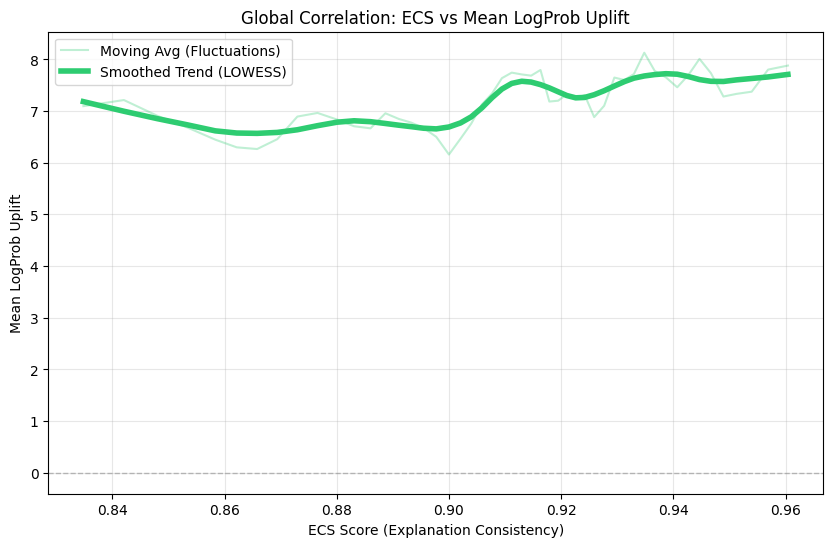

🎉 Done.


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. CONFIGURATION
# -----------------------------
ECS_FILE    = "gsm8k/gsm8k_llama3_with_ECS.csv"
UPLIFT_FILE = "gsm8k/gsm8k_logprob_uplift.csv"  # Updated file

# *** Add IDs to exclude here ***
EXCLUDE_IDS = []

# Plot Parameters
WINDOW_SIZE = 50
STEP_SIZE   = 5
SMOOTHING   = 0.25

# Visualization Settings
METRIC_COL   = "mean_uplift"       # Updated column
METRIC_LABEL = "Mean LogProb Uplift"
PLOT_COLOR   = "#2ecc71"           # Green (Distinct for uplift)

# -----------------------------
# 2. LOAD & MERGE DATA
# -----------------------------
print("📂 Loading Data...")
try:
    df_ecs = pd.read_csv(ECS_FILE, dtype={"id": str})
    df_uplift = pd.read_csv(UPLIFT_FILE, dtype={"id": str})
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("   Please ensure the files exist in the 'gsm8k' folder.")
    exit()

# Normalize IDs (strip whitespace to ensure matching)
df_ecs["id"] = df_ecs["id"].astype(str).str.strip()
df_uplift["id"] = df_uplift["id"].astype(str).str.strip()

# *** Apply Exclusion Filter ***
if EXCLUDE_IDS:
    print(f"🚫 Excluding {len(EXCLUDE_IDS)} IDs from analysis...")
    before_len_ecs = len(df_ecs)
    before_len_uplift = len(df_uplift)
    
    # Filter both dataframes
    df_ecs = df_ecs[~df_ecs["id"].isin(EXCLUDE_IDS)]
    df_uplift = df_uplift[~df_uplift["id"].isin(EXCLUDE_IDS)]
    
    print(f"   - ECS rows: {before_len_ecs} -> {len(df_ecs)}")
    print(f"   - Uplift rows: {before_len_uplift} -> {len(df_uplift)}")

# Verify Columns Exist
if "ECS" not in df_ecs.columns:
    raise ValueError(f"Could not find 'ECS' column in {ECS_FILE}")
if METRIC_COL not in df_uplift.columns:
    print(f"Available columns in uplift file: {df_uplift.columns.tolist()}")
    raise ValueError(f"Could not find '{METRIC_COL}' column in {UPLIFT_FILE}")

# Merge ECS with Uplift Data
# Using inner merge to only keep rows present in both files
df_merged = pd.merge(df_uplift[[METRIC_COL, "id"]], df_ecs[["id", "ECS"]], on="id", how="inner")

print(f"🔗 Merged Data: {len(df_merged)} rows (matched IDs)")

# -----------------------------
# 3. PLOTTING FUNCTION
# -----------------------------
def plot_trend(ax, data, x_col, y_col, color_hex):
    # Drop NaNs just in case
    clean = data.dropna(subset=[x_col, y_col]).copy()
    
    if len(clean) < WINDOW_SIZE:
        print(f"⚠️ Not enough data to plot (need ≥ {WINDOW_SIZE}, have {len(clean)})")
        return False

    # Sort by ECS for sliding window
    clean = clean.sort_values(x_col).reset_index(drop=True)

    # Calculate Sliding Window Averages
    avg_x, avg_y = [], []
    for start in range(0, len(clean) - WINDOW_SIZE + 1, STEP_SIZE):
        window = clean.iloc[start : start + WINDOW_SIZE]
        avg_x.append(window[x_col].mean())
        avg_y.append(window[y_col].mean())

    if not avg_x:
        print("⚠️ Sliding window resulted in empty data.")
        return False

    # 1. Plot Raw Moving Average (Light/Transparent)
    ax.plot(
        avg_x, avg_y,
        color=color_hex,
        alpha=0.3,
        linewidth=1.5,
        label="Moving Avg (Fluctuations)",
    )

    # 2. Plot LOWESS Smoothed Trend (Bold)
    try:
        smooth = lowess(avg_y, avg_x, frac=SMOOTHING, return_sorted=True)
        ax.plot(
            smooth[:, 0], smooth[:, 1],
            color=color_hex,
            linewidth=4,
            label="Smoothed Trend (LOWESS)",
        )
    except Exception as e:
        print(f"⚠️ LOWESS smoothing failed: {e}")
        # Fallback: just plot the moving average more boldly if LOWESS fails
        ax.plot(avg_x, avg_y, color=color_hex, linewidth=2, label="Trend")
        
    return True

# -----------------------------
# 4. GENERATE PLOT
# -----------------------------
print(f"🎨 Generating Plot for {METRIC_LABEL}...")

fig, ax = plt.subplots(figsize=(10, 6))

# Execute Plotting
success = plot_trend(ax, df_merged, "ECS", METRIC_COL, PLOT_COLOR)

if success:
    # Styling
    ax.set_xlabel("ECS Score (Explanation Consistency)")
    ax.set_ylabel(METRIC_LABEL)
    ax.set_title(f"Global Correlation: ECS vs {METRIC_LABEL}")
    
    # Add a zero line for reference (Uplift often centers around 0)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.5)

    ax.legend(loc="best")
    ax.grid(alpha=0.3)

    # Save
    filename = "Plot_ECS_vs_Uplift.png"
    plt.savefig(filename, dpi=300)
    print(f"✅ Saved: {filename}")
    plt.show()
else:
    print("❌ Plot generation failed due to insufficient data.")
    plt.close(fig)

print("🎉 Done.")